# פרויקט לימוד מכונה - חלק ב'

במחברת זו נבנה תהליך עבודה מסודר עבור חלק ב' של הפרויקט: טעינת הנתונים, הכנתם לאימון, חלוקה לסט אימון וסט אימות, ובהמשך אימון והשוואה בין מודלים שונים.

בשלב הנוכחי המחברת כוללת את שלד העבודה ואת שלב טעינת והכנת הנתונים בלבד. סעיפי המודלים מופיעים ככותרות להמשך, אך עדיין לא ממומשים.

## 1. ייבוא ספריות והגדרות ראשוניות

נייבא ספריות בסיסיות הדרושות לטעינת הנתונים, בדיקה ראשונית וחלוקה לסט אימון וסט אימות. בהמשך נוסיף ספריות נוספות רק כאשר נגיע לסעיפי המודלים.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd


RANDOM_STATE = 42

## 2. טעינת קבצי הנתונים

נטען את קובץ האימון, קובץ המבחן הסופי וקובץ הדוגמה להגשה. בשלב זה קובץ המבחן הסופי משמש רק לבדיקת מבנה, ולא לבחירת מודלים או לכוונון שלהם.

In [ ]:
from pathlib import Path
import pandas as pd

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BASE_DIR = Path.cwd()

TRAIN_FILE = BASE_DIR / "Xy_train.csv"
TEST_FILE = BASE_DIR / "X_test.csv"
EXAMPLE_SUBMISSION_FILE = BASE_DIR / "y test example.xlsx"

required_files = [TRAIN_FILE, TEST_FILE, EXAMPLE_SUBMISSION_FILE]

missing_files = [
    file_path.name
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    print("הקבצים הבאים חסרים:")
    print(missing_files)

    if IN_COLAB:
        print("בחרי והעלי עכשיו את הקבצים החסרים:")
        uploaded = files.upload()
    else:
        raise FileNotFoundError(f"הקבצים הבאים חסרים בתיקיית העבודה: {missing_files}")

# בדיקה חוזרת אחרי ההעלאה
missing_files = [
    file_path.name
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(f"עדיין חסרים הקבצים הבאים: {missing_files}")

train_raw = pd.read_csv(TRAIN_FILE)
test_raw = pd.read_csv(TEST_FILE)
example_submission = pd.read_excel(EXAMPLE_SUBMISSION_FILE)

display(train_raw.head())
display(test_raw.head())
display(example_submission.head())

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Plane colors,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,35.0,Personal Travel,Eco,731.0,2,4.0,3.0,1.0,...,3.0,4.0,NaN,5.0,1.0,5.0,2.0,18.0,1.0,neutral or dissatisfied
1,Female,Loyal Customer,35.0,Business travel,Unknown,354.0,2,3.0,3.0,3.0,...,3.0,2.0,3.0,3.0,1.0,3.0,3.0,0.0,0.0,neutral or dissatisfied
2,Male,disloyal Customer,43.0,Business travel,Eco,719.0,3,2.0,2.0,2.0,...,2.0,1.0,3.0,1.0,2.0,4.0,4.0,0.0,0.0,neutral or dissatisfied
3,Male,disloyal Customer,21.0,Business travel,Eco,772.0,1,2.0,2.0,2.0,...,2.0,3.0,3.0,3.0,3.0,5.0,2.0,11.0,7.0,neutral or dissatisfied
4,Male,Loyal Customer,39.0,Personal Travel,Eco,618.0,1,4.0,2.0,4.0,...,2.0,4.0,NaN,3.0,3.0,5.0,2.0,0.0,0.0,neutral or dissatisfied


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Plane colors,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Food and drink,Seat comfort,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,Female,Loyal Customer,69,Personal Travel,Eco,363,2,2,5,2,...,1,5,3,5.0,3,3,3,4,0,0.0
1,Female,disloyal Customer,11,Business travel,Eco,231,2,2,0,2,...,1,1,4,2.0,4,3,5,1,0,0.0
2,Female,Loyal Customer,38,Business travel,Business,3394,2,5,5,0,...,2,5,5,NaN,5,4,5,3,13,28.0
3,Female,Loyal Customer,55,Business travel,Business,2340,1,5,5,5,...,2,5,4,4.0,4,4,4,4,108,107.0
4,Female,disloyal Customer,72,Business travel,Eco,129,1,4,5,4,...,4,2,1,3.0,5,5,2,2,14,22.0


,target
0,1
1,0
2,0
3,0
4,1


## 3. בדיקות מבנה בסיסיות

נבדוק את גודל הקבצים, שמות העמודות, ערכים חסרים וכפילויות. בדיקות אלה נועדו לוודא שאנחנו עובדים עם הקבצים הנכונים לפני שמתחילים לבנות מודלים.

In [ ]:
data_summary = pd.DataFrame(
    {
        "קובץ": ["אימון", "מבחן סופי", "דוגמת הגשה"],
        "מספר שורות": [len(train_raw), len(test_raw), len(example_submission)],
        "מספר עמודות": [train_raw.shape[1], test_raw.shape[1], example_submission.shape[1]],
        "מספר ערכים חסרים": [
            int(train_raw.isna().sum().sum()),
            int(test_raw.isna().sum().sum()),
            int(example_submission.isna().sum().sum()),
        ],
        "מספר שורות כפולות": [
            int(train_raw.duplicated().sum()),
            int(test_raw.duplicated().sum()),
            int(example_submission.duplicated().sum()),
        ],
    }
)

display(data_summary)

,קובץ,מספר שורות,מספר עמודות,מספר ערכים חסרים,מספר שורות כפולות
0,אימון,9000,22,3196,0
1,מבחן סופי,1000,21,354,0
2,דוגמת הגשה,185,1,0,183


In [ ]:
columns_summary = pd.DataFrame(
    {
        "עמודות בקובץ האימון": pd.Series(train_raw.columns),
        "עמודות בקובץ המבחן הסופי": pd.Series(test_raw.columns),
        "עמודות בקובץ הדוגמה": pd.Series(example_submission.columns),
    }
)

display(columns_summary)

,עמודות בקובץ האימון,עמודות בקובץ המבחן הסופי,עמודות בקובץ הדוגמה
0,Gender,Gender,target
1,Customer Type,Customer Type,NaN
2,Age,Age,NaN
3,Type of Travel,Type of Travel,NaN
4,Class,Class,NaN
5,Flight Distance,Flight Distance,NaN
6,Plane colors,Plane colors,NaN
7,Inflight wifi service,Inflight wifi service,NaN
8,Departure/Arrival time convenient,Departure/Arrival time convenient,NaN
9,Ease of Online booking,Ease of Online booking,NaN


In [ ]:
missing_summary = pd.DataFrame(
    {
        "חסרים באימון": train_raw.isna().sum(),
        "חסרים במבחן הסופי": test_raw.isna().sum(),
    }
).fillna(0).astype(int)

display(missing_summary)

,חסרים באימון,חסרים במבחן הסופי
Age,1,0
Arrival Delay in Minutes,471,54
Baggage handling,1,0
Checkin service,1,0
Class,1,0
Cleanliness,1,0
Customer Type,1,0
Departure Delay in Minutes,1,0
Departure/Arrival time convenient,2,0
Ease of Online booking,2,0


## 4. זיהוי עמודת המטרה והפרדת מאפיינים

נזהה את עמודת המטרה מתוך קובץ האימון בפועל. לא נניח מראש את שם העמודה או את צורת הכתיבה שלה. לאחר הזיהוי נפריד בין מאפייני הקלט לבין משתנה המטרה.

In [ ]:
train_columns = list(train_raw.columns)
test_columns = list(test_raw.columns)

columns_only_in_train = [column for column in train_columns if column not in test_columns]

if len(columns_only_in_train) != 1:
    raise ValueError(
        "לא ניתן לזהות באופן חד-משמעי את עמודת המטרה. "
        f"עמודות שמופיעות רק באימון: {columns_only_in_train}"
    )

target_column = columns_only_in_train[0]
feature_columns = [column for column in train_columns if column != target_column]

missing_in_test = [column for column in feature_columns if column not in test_columns]
extra_in_test = [column for column in test_columns if column not in feature_columns]

if missing_in_test or extra_in_test:
    raise ValueError(
        "מבנה עמודות המאפיינים באימון ובמבחן הסופי אינו תואם. "
        f"חסרות במבחן: {missing_in_test}; עודפות במבחן: {extra_in_test}"
    )

X = train_raw[feature_columns].copy()
y = train_raw[target_column].copy()
X_test_final = test_raw[feature_columns].copy()

print(f"עמודת המטרה שזוהתה: {target_column}")
print(f"מספר מאפיינים: {len(feature_columns)}")

עמודת המטרה שזוהתה: satisfaction
מספר מאפיינים: 21


In [ ]:
target_distribution = (
    y.value_counts(dropna=False)
    .rename_axis("ערך המטרה")
    .reset_index(name="מספר רשומות")
)
target_distribution["אחוז"] = (target_distribution["מספר רשומות"] / len(y) * 100).round(2)

display(target_distribution)

,ערך המטרה,מספר רשומות,אחוז
0,neutral or dissatisfied,5071,56.34
1,satisfied,3928,43.64
2,NaN,1,0.01


## 5. ניקוי נתונים לפי החלטות חלק א'

ניישם בתוך המחברת את לוגיקת הניקוי המתוקנת מחלק א'. קבצי המקור נשארים ללא שינוי, והטבלאות הנקיות נשמרות בזיכרון המחברת בלבד.

בקובץ האימון מותר להסיר רשומות לא תקינות כאשר זה נעשה במחברת המתוקנת. בקובץ המבחן הסופי לא נמחק רשומות ולא נשנה את סדר הרשומות, כדי שקובץ החיזויים הסופי יתאים בדיוק לקובץ המקור.

רשומות ללא ערך במשתנה המטרה אינן יכולות לשמש ללמידה מפוקחת, ולכן נסיר אותן רק מנתוני האימון. לקובץ המבחן הסופי אין משתנה מטרה, ולכן לעולם לא נסיר ממנו רשומות.

In [ ]:
service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Seat comfort",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness",
]

numeric_like_columns = [
    "Age",
    "Flight Distance",
    "Plane colors",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
    *service_columns,
]

engineered_features = ["Age_Category", "Flight_Type", "Total_Service_Score"]


def apply_corrected_part_a_cleaning(df_to_clean, is_train=True, target_column_name=None):
    df_clean = df_to_clean.copy()
    original_index = df_clean.index.copy()
    original_rows = len(df_clean)
    summary = {"מספר שורות לפני ניקוי": original_rows}

    for column in numeric_like_columns:
        if column in df_clean.columns:
            df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

    # 1. זיהוי והסרת ערכי Class לא תקינים באימון בלבד
    removed_invalid_class_rows = 0
    removed_missing_target_rows = 0
    if "Class" in df_clean.columns:
        valid_classes = ["Eco", "Eco Plus", "Business", "Unknown"]
        missing_class_mask = df_clean["Class"].isna()
        invalid_class_mask = (~df_clean["Class"].isin(valid_classes)) & df_clean["Class"].notna()
        summary["ערכי Class חסרים שהוחלפו"] = int(missing_class_mask.sum())
        summary["ערכי Class לא תקינים"] = int(invalid_class_mask.sum())

        if is_train:
            removed_invalid_class_rows = int(invalid_class_mask.sum())
            df_clean = df_clean.drop(index=df_clean.index[invalid_class_mask]).copy()
        else:
            df_clean.loc[invalid_class_mask, "Class"] = np.nan

        # 2. החלפת Class חסר ו-Unknown ב-Business
        missing_class_mask = df_clean["Class"].isna()
        unknown_mask = df_clean["Class"] == "Unknown"
        summary["ערכי Unknown ב-Class שהוחלפו"] = int(unknown_mask.sum())
        df_clean.loc[missing_class_mask | unknown_mask, "Class"] = "Business"

    # 3. טיפול בערכי Gate location חריגים והשלמה לפי חציון
    if "Gate location" in df_clean.columns:
        invalid_gate_mask = (~df_clean["Gate location"].between(1, 5)) & df_clean["Gate location"].notna()
        summary["ערכי Gate location חריגים"] = int(invalid_gate_mask.sum())
        df_clean.loc[invalid_gate_mask, "Gate location"] = np.nan
        gate_median = df_clean["Gate location"].median()
        df_clean["Gate location"] = df_clean["Gate location"].fillna(gate_median)
        summary["חציון Gate location להשלמה"] = gate_median

    # 4. השלמת Leg room service לפי Class + Type of Travel, אחר כך Class, אחר כך חציון כללי
    if {"Leg room service", "Class", "Type of Travel"}.issubset(df_clean.columns):
        leg_missing_before = int(df_clean["Leg room service"].isna().sum())
        group_median_1 = df_clean.groupby(["Class", "Type of Travel"])["Leg room service"].transform("median")
        group_median_2 = df_clean.groupby("Class")["Leg room service"].transform("median")
        global_median = df_clean["Leg room service"].median()

        df_clean["Leg room service"] = df_clean["Leg room service"].fillna(group_median_1)
        df_clean["Leg room service"] = df_clean["Leg room service"].fillna(group_median_2)
        df_clean["Leg room service"] = df_clean["Leg room service"].fillna(global_median)

        summary["חסרי Leg room service לפני השלמה"] = leg_missing_before
        summary["חציון כללי Leg room service"] = global_median

    # 5. טיפול בערכי Age חריגים והשלמה לפי חציון
    if "Age" in df_clean.columns:
        invalid_age_mask = ((df_clean["Age"] < 0) | (df_clean["Age"] > 110)) & df_clean["Age"].notna()
        summary["ערכי Age חריגים"] = int(invalid_age_mask.sum())
        df_clean.loc[invalid_age_mask, "Age"] = np.nan
        age_median = df_clean["Age"].median()
        df_clean["Age"] = df_clean["Age"].fillna(age_median)
        summary["חציון Age להשלמה"] = age_median

    # 6. טיפול בערכי Flight Distance שליליים והשלמה היררכית
    if {"Flight Distance", "Class", "Type of Travel"}.issubset(df_clean.columns):
        negative_distance_mask = (df_clean["Flight Distance"] < 0) & df_clean["Flight Distance"].notna()
        summary["ערכי Flight Distance שליליים"] = int(negative_distance_mask.sum())
        df_clean.loc[negative_distance_mask, "Flight Distance"] = np.nan

        distance_median_group_1 = df_clean.groupby(["Class", "Type of Travel"])["Flight Distance"].transform("median")
        distance_median_group_2 = df_clean.groupby("Class")["Flight Distance"].transform("median")
        distance_global_median = df_clean["Flight Distance"].median()

        df_clean["Flight Distance"] = df_clean["Flight Distance"].fillna(distance_median_group_1)
        df_clean["Flight Distance"] = df_clean["Flight Distance"].fillna(distance_median_group_2)
        df_clean["Flight Distance"] = df_clean["Flight Distance"].fillna(distance_global_median)
        summary["חציון כללי Flight Distance"] = distance_global_median

    # 7. הסרת Plane colors מתוך הטבלה שכבר נוקתה, בלי לחזור לטבלת המקור
    if "Plane colors" in df_clean.columns:
        df_clean = df_clean.drop(columns=["Plane colors"])
        summary["Plane colors הוסר"] = True
    else:
        summary["Plane colors הוסר"] = False

    # לפני השלמה כללית, מסירים באימון בלבד רשומות ללא משתנה מטרה
    if is_train and target_column_name is not None and target_column_name in df_clean.columns:
        missing_target_mask = df_clean[target_column_name].isna()
        removed_missing_target_rows = int(missing_target_mask.sum())
        if removed_missing_target_rows > 0:
            df_clean = df_clean.drop(index=df_clean.index[missing_target_mask]).copy()

    # 8. השלמת חסרים מספריים שנותרו לפי חציון
    numeric_cols = [
        col for col in df_clean.select_dtypes(include=[np.number]).columns
        if col != target_column_name
    ]
    for col in numeric_cols:
        if df_clean[col].isna().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # 9. השלמת חסרים קטגוריאליים שנותרו לפי שכיח
    categorical_cols = [
        col for col in df_clean.select_dtypes(include=["object"]).columns
        if col != target_column_name
    ]
    for col in categorical_cols:
        if df_clean[col].isna().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    # 10. יצירת מאפיינים חדשים כמו במחברת המתוקנת
    if "Age" in df_clean.columns:
        df_clean["Age_Category"] = pd.cut(
            df_clean["Age"],
            bins=[0, 12, 18, 65, np.inf],
            labels=["Child", "Teen", "Adult", "Senior"],
            include_lowest=True,
        )

    if "Flight Distance" in df_clean.columns:
        df_clean["Flight_Type"] = pd.cut(
            df_clean["Flight Distance"],
            bins=[0, 1000, 3000, df_clean["Flight Distance"].max()],
            labels=["Short-Haul", "Medium-Haul", "Long-Haul"],
            include_lowest=True,
        )

    available_service_columns = [column for column in service_columns if column in df_clean.columns]
    if available_service_columns:
        df_clean["Total_Service_Score"] = df_clean[available_service_columns].mean(axis=1)

    summary["מספר שורות אחרי ניקוי"] = len(df_clean)
    summary["רשומות Class שהוסרו"] = removed_invalid_class_rows
    summary["רשומות שהוסרו בגלל יעד חסר"] = removed_missing_target_rows
    summary["סך ערכים חסרים אחרי ניקוי"] = int(df_clean.isna().sum().sum())
    summary["מאפיינים הנדסיים נוצרו"] = all(feature in df_clean.columns for feature in engineered_features)
    summary["סדר מקורי נשמר"] = df_clean.index.equals(original_index)

    return df_clean, summary


train_for_cleaning = X.copy()
train_for_cleaning[target_column] = y

train_clean, train_cleaning_summary = apply_corrected_part_a_cleaning(
    train_for_cleaning,
    is_train=True,
    target_column_name=target_column,
)

X_test_clean, test_cleaning_summary = apply_corrected_part_a_cleaning(
    X_test_final,
    is_train=False,
    target_column_name=None,
)

X_model = train_clean.drop(columns=[target_column]).copy()
y_model = train_clean[target_column].copy()
X_test_final = X_test_clean.copy()

missing_in_clean_test = [column for column in X_model.columns if column not in X_test_final.columns]
extra_in_clean_test = [column for column in X_test_final.columns if column not in X_model.columns]

if missing_in_clean_test or extra_in_clean_test:
    raise ValueError(
        "מבנה המאפיינים לאחר הניקוי אינו תואם בין אימון למבחן. "
        f"חסרות במבחן: {missing_in_clean_test}; עודפות במבחן: {extra_in_clean_test}"
    )

X_test_final = X_test_final[X_model.columns].copy()

cleaning_summary = pd.DataFrame([train_cleaning_summary, test_cleaning_summary], index=["אימון", "מבחן סופי"])
display(cleaning_summary)

print("הנתונים נוקו בתוך המחברת בלבד. קבצי המקור לא שונו.")

,מספר שורות לפני ניקוי,ערכי Class חסרים שהוחלפו,ערכי Class לא תקינים,ערכי Unknown ב-Class שהוחלפו,ערכי Gate location חריגים,חציון Gate location להשלמה,חסרי Leg room service לפני השלמה,חציון כללי Leg room service,ערכי Age חריגים,חציון Age להשלמה,ערכי Flight Distance שליליים,חציון כללי Flight Distance,Plane colors הוסר,מספר שורות אחרי ניקוי,רשומות Class שהוסרו,רשומות שהוסרו בגלל יעד חסר,סך ערכים חסרים אחרי ניקוי,מאפיינים הנדסיים נוצרו,סדר מקורי נשמר
אימון,9000,1,1,1311,1,3.0,2701,3.0,2,41.0,1,853.5,True,8998,1,1,0,True,False
מבחן סופי,1000,0,0,143,0,3.0,300,3.0,0,40.5,0,861.5,True,1000,0,0,0,True,True


הנתונים נוקו בתוך המחברת בלבד. קבצי המקור לא שונו.


### בדיקות לאחר הניקוי

נציג בדיקות שמוודאות שהניקוי בוצע לפי החלטות חלק א', ושקובץ המבחן הסופי נשמר באותו אורך ובאותו סדר.

In [ ]:
rows_check = pd.DataFrame(
    {
        "קובץ": ["אימון", "מבחן סופי"],
        "שורות לפני ניקוי": [len(train_raw), len(test_raw)],
        "שורות אחרי ניקוי": [len(train_clean), len(X_test_final)],
        "שורות שהוסרו בגלל יעד חסר": [train_cleaning_summary["רשומות שהוסרו בגלל יעד חסר"], 0],
    }
)

display(rows_check)

test_order_preserved = X_test_final.index.equals(test_raw.index)
test_row_count_preserved = len(X_test_final) == len(test_raw)

print(f"מספר שורות בקובץ המבחן נשמר: {test_row_count_preserved}")
print(f"סדר הרשומות בקובץ המבחן נשמר: {test_order_preserved}")
print(f"מספר שורות אימון שהוסרו בגלל יעד חסר: {train_cleaning_summary['רשומות שהוסרו בגלל יעד חסר']}")

missing_after_cleaning = pd.DataFrame(
    {
        "חסרים במאפייני X באימון לאחר ניקוי": X_model.isna().sum(),
        "חסרים במבחן לאחר ניקוי": X_test_final.isna().sum(),
    }
).fillna(0).astype(int)

display(missing_after_cleaning)

missing_y_after_cleaning = int(y_model.isna().sum())
print(f"חסרים ב-y לאחר ניקוי: {missing_y_after_cleaning}")

plane_colors_removed = ("Plane colors" not in train_clean.columns) and ("Plane colors" not in X_test_final.columns)
engineered_features_created = all(
    feature in train_clean.columns and feature in X_test_final.columns
    for feature in engineered_features
)

print(f"Plane colors הוסר מהאימון ומהמבחן: {plane_colors_removed}")
print(f"המאפיינים Age_Category, Flight_Type, Total_Service_Score נוצרו: {engineered_features_created}")

assert test_row_count_preserved
assert test_order_preserved
assert X_model.isna().sum().sum() == 0
assert missing_y_after_cleaning == 0
assert X_test_final.isna().sum().sum() == 0
assert plane_colors_removed
assert engineered_features_created

,קובץ,שורות לפני ניקוי,שורות אחרי ניקוי,שורות שהוסרו בגלל יעד חסר
0,אימון,9000,8998,1
1,מבחן סופי,1000,1000,0


מספר שורות בקובץ המבחן נשמר: True
סדר הרשומות בקובץ המבחן נשמר: True
מספר שורות אימון שהוסרו בגלל יעד חסר: 1


,חסרים במאפייני X באימון לאחר ניקוי,חסרים במבחן לאחר ניקוי
Gender,0,0
Customer Type,0,0
Age,0,0
Type of Travel,0,0
Class,0,0
Flight Distance,0,0
Inflight wifi service,0,0
Departure/Arrival time convenient,0,0
Ease of Online booking,0,0
Gate location,0,0


חסרים ב-y לאחר ניקוי: 0
Plane colors הוסר מהאימון ומהמבחן: True
המאפיינים Age_Category, Flight_Type, Total_Service_Score נוצרו: True


## 6. הכנת נתונים ראשונית לאימון ולאימות

לאחר ניקוי הנתונים בתוך המחברת, נשתמש בטבלת האימון הנקייה ובטבלת המבחן הנקייה בזיכרון. קובץ המבחן הסופי עדיין לא ישמש לאימון, לבחירת מודלים או לכוונון.

In [ ]:
if y_model.isna().any():
    raise ValueError("נמצאו ערכים חסרים בעמודת המטרה לאחר הניקוי. יש לטפל בכך לפני חלוקת הנתונים.")

original_test_index = X_test_final.index.copy()
original_test_length = len(X_test_final)

print("הנתונים הנקיים מוכנים לחלוקה ראשונית לאימון ולאימות.")

הנתונים הנקיים מוכנים לחלוקה ראשונית לאימון ולאימות.


## 7. חלוקה לסט אימון וסט אימות

נחלק את קובץ האימון הנקי לסט אימון ולסט אימות. סט האימות יישמר בצד וישמש להערכת ביצועי המודלים על נתונים שלא שימשו לאימון. קובץ המבחן הסופי נשאר מחוץ לתהליך זה.

In [ ]:
from sklearn.model_selection import train_test_split

stratify_target = y_model if y_model.nunique(dropna=False) > 1 else None

X_train, X_valid, y_train, y_valid = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_target,
)

split_summary = pd.DataFrame(
    {
        "סט": ["אימון", "אימות", "מבחן סופי"],
        "מספר רשומות": [len(X_train), len(X_valid), len(X_test_final)],
        "מספר מאפיינים": [X_train.shape[1], X_valid.shape[1], X_test_final.shape[1]],
    }
)

display(split_summary)

,סט,מספר רשומות,מספר מאפיינים
0,אימון,7198,23
1,אימות,1800,23
2,מבחן סופי,1000,23


In [ ]:
train_target_distribution = y_train.value_counts(normalize=True, dropna=False).rename("אימון")
valid_target_distribution = y_valid.value_counts(normalize=True, dropna=False).rename("אימות")

split_target_distribution = (
    pd.concat([train_target_distribution, valid_target_distribution], axis=1)
    .fillna(0)
    .mul(100)
    .round(2)
)

display(split_target_distribution)

,אימון,אימות
satisfaction,,
neutral or dissatisfied,56.36,56.33
satisfied,43.64,43.67


In [ ]:
assert len(X_test_final) == original_test_length
assert X_test_final.index.equals(original_test_index)

print("בדיקת קובץ המבחן הסופי הסתיימה: מספר השורות והסדר המקורי נשמרו.")

בדיקת קובץ המבחן הסופי הסתיימה: מספר השורות והסדר המקורי נשמרו.


## 8. עצי החלטה

בסעיף זה נבנה בהמשך עץ החלטה מלא, נכוונן היפר-פרמטרים, נציג את העץ הנבחר, ננתח חשיבות משתנים ונעביר רשומת אימות לדוגמה דרך העץ.

### 8.1 הכנת הנתונים לעץ החלטה (Data Preparation)

עבור מודל עץ החלטה (Decision Tree), נכין את הנתונים באופן הבא:
1. **קידוד משתנים קטגוריאליים (One-Hot Encoding)**: נמיר את המשתנים הקטגוריאליים (`Gender`, `Customer Type`, `Type of Travel`, `Class`, והמשתנים ההנדסיים `Age_Category`, `Flight_Type`) למשתני דמה (dummy variables). משתנים אלו יקודדו באמצעות `OneHotEncoder(handle_unknown="ignore")`.
2. **אי-החלת סקיילינג (No Scaling)**: בניגוד לרשתות נוירונים, עצי החלטה אינם רגישים לסקאלה של המשתנים המספריים משום שהם מבצעים פיצולים מקומיים על פי ערכי סף של משתנה בודד בכל פעם. לכן, לא נבצע סטנדרטיזציה (`StandardScaler`) על המשתנים המספריים.
3. **מיפוי משתנה המטרה**: נמיר את עמודת המטרה `satisfaction` לערכים בינאריים (0 עבור `neutral or dissatisfied` ו-1 עבור `satisfied`).
4. **ערכים חסרים**: נציין כי הטיפול בערכים חסרים בוצע באופן מלא בשלב הניקוי הכללי (סעיף 5), כך שאין ערכים חסרים בנתונים המגיעים לסעיף זה.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

# 1. מיפוי משתנה המטרה לבינארי
TARGET_MAP = {
    'neutral or dissatisfied': 0,
    'satisfied': 1
}

y_train_dt = y_train.map(TARGET_MAP).astype(int)
y_valid_dt = y_valid.map(TARGET_MAP).astype(int)

print('Target variable mapped successfully.')

Target variable mapped successfully.


In [ ]:
# 2. זיהוי עמודות מספריות וקטגוריאליות
numeric_features_dt = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_dt = [col for col in X_train.columns if col not in numeric_features_dt]

def make_dt_preprocessor():
    try:
        one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

    return ColumnTransformer(
        transformers=[
            # מותירים את המשתנים המספריים ללא שינוי (passthrough) וללא StandardScaler
            ('numeric', 'passthrough', numeric_features_dt),
            ('categorical', one_hot_encoder, categorical_features_dt),
        ],
        remainder='drop',
    )

def build_dt_pipeline(model):
    return Pipeline(
        steps=[
            ('preprocess', make_dt_preprocessor()),
            ('model', model),
        ]
    )

dt_preprocessing_summary = pd.DataFrame(
    {
        'סוג משתנים': ['מספריים', 'קטגוריאליים'],
        'מספר משתנים': [len(numeric_features_dt), len(categorical_features_dt)],
        'פעולת עיבוד': ['מעבר ללא שינוי (passthrough)', 'One-Hot Encoding'],
    }
)
display(dt_preprocessing_summary)

,סוג משתנים,מספר משתנים,פעולת עיבוד
0,מספריים,17,מעבר ללא שינוי (passthrough)
1,קטגוריאליים,6,One-Hot Encoding


### 8.2 בניית עץ החלטה מלא (Full Decision Tree)

נאמן עץ החלטה מלא ללא מגבלת עומק או פיצול (ערכי ברירת מחדל של `DecisionTreeClassifier` מלבד ה-`random_state`). נחשב את מדדי הביצוע על סט האימון וסט האימות, ונציג אותם בגרף עמודות.

שי שינתה את הקוד למטה

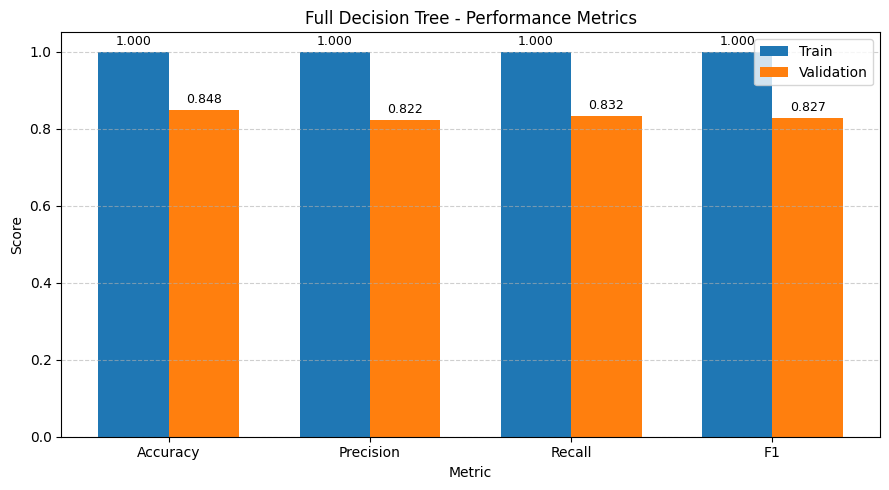

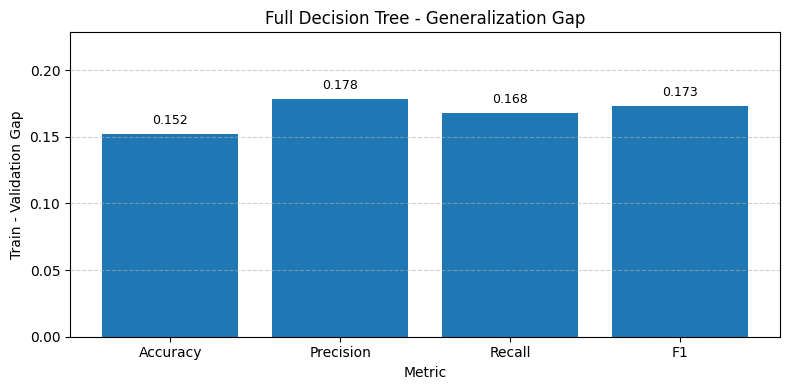

Performance metrics:


,Dataset,Accuracy,Precision,Recall,F1
0,Train,1.000000,1.000000,1.000000,1.000000
1,Validation,0.847778,0.821608,0.832061,0.826802


Generalization gap:


,Metric,Train,Validation,Gap (Train - Validation)
0,Accuracy,1.0,0.847778,0.152222
1,Precision,1.0,0.821608,0.178392
2,Recall,1.0,0.832061,0.167939
3,F1,1.0,0.826802,0.173198


In [ ]:
# עץ החלטה מלא - אימון, הערכה והצגת תוצאות

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. בניית מודל עץ החלטה מלא
# לא מגבילים את עומק העץ או את מספר הפיצולים, כדי לבדוק איך עץ מלא מתנהג
full_dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)

# 2. חיבור המודל לצינור העיבוד המקדים
# הצינור כולל את שלב עיבוד הנתונים ואת המודל עצמו
full_dt_pipeline = build_dt_pipeline(full_dt_model)

# 3. אימון המודל על סט האימון
full_dt_pipeline.fit(X_train, y_train_dt)


# 4. פונקציה להערכת ביצועי המודל ולהצגת גרפים
def evaluate_full_decision_tree(model_name, fitted_pipeline, return_metrics=False):

    # נשמור כאן את מדדי הביצוע של המודל
    metrics = []

    # נבדוק את המודל גם על סט האימון וגם על סט האימות
    splits = [
        ('Train', X_train, y_train_dt),
        ('Validation', X_valid, y_valid_dt)
    ]

    # חישוב מדדי הביצוע לכל סט נתונים
    for split_name, X_data, y_true in splits:

        # חיזוי ערכי המטרה באמצעות המודל
        y_pred = fitted_pipeline.predict(X_data)

        # חישוב המדדים ושמירתם בטבלה
        metrics.append({
            'Dataset': split_name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1': f1_score(y_true, y_pred, zero_division=0)
        })

    # יצירת טבלת ביצועים
    df_metrics = pd.DataFrame(metrics)

    # רשימת המדדים שנרצה להציג
    metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1']

    # חילוץ ערכי המדדים עבור סט האימון וסט האימות
    train_values = df_metrics.loc[df_metrics['Dataset'] == 'Train', metric_cols].iloc[0]
    valid_values = df_metrics.loc[df_metrics['Dataset'] == 'Validation', metric_cols].iloc[0]

    # יצירת טבלת פערים בין ביצועי האימון לביצועי האימות
    # פער גדול מצביע על חשש להתאמת יתר
    gap_df = pd.DataFrame({
        'Metric': metric_cols,
        'Train': train_values.values,
        'Validation': valid_values.values,
        'Gap (Train - Validation)': train_values.values - valid_values.values
    })

    # -------------------------------------------------
    # גרף 1: השוואת ביצועים בין סט האימון לסט האימות
    # -------------------------------------------------

    x = np.arange(len(metric_cols))
    width = 0.35

    plt.figure(figsize=(9, 5))

    train_bars = plt.bar(
        x - width / 2,
        gap_df['Train'],
        width,
        label='Train'
    )

    valid_bars = plt.bar(
        x + width / 2,
        gap_df['Validation'],
        width,
        label='Validation'
    )

    plt.title(f'{model_name} - Performance Metrics')
    plt.xlabel('Metric')
    plt.ylabel('Score')
    plt.xticks(x, metric_cols)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # הוספת ערכים מספריים מעל העמודות
    for bars in [train_bars, valid_bars]:
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01,
                f'{height:.3f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # גרף 2: פער ההכללה בין סט האימון לסט האימות
    # -------------------------------------------------

    plt.figure(figsize=(8, 4))

    gap_bars = plt.bar(
        gap_df['Metric'],
        gap_df['Gap (Train - Validation)']
    )

    plt.title(f'{model_name} - Generalization Gap')
    plt.xlabel('Metric')
    plt.ylabel('Train - Validation Gap')
    plt.ylim(0, gap_df['Gap (Train - Validation)'].max() + 0.05)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # הוספת ערכים מספריים מעל העמודות
    for bar in gap_bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

    # הצגת טבלאות הביצועים והפערים
    print("Performance metrics:")
    display(df_metrics)

    print("Generalization gap:")
    display(gap_df)

    # החזרת הטבלאות לשימוש בהמשך המחברת
    if return_metrics:
        return df_metrics, gap_df


# 5. הרצת פונקציית ההערכה עבור עץ ההחלטה המלא
full_dt_metrics, full_dt_gap = evaluate_full_decision_tree(
    model_name='Full Decision Tree',
    fitted_pipeline=full_dt_pipeline,
    return_metrics=True
)

<mark> **מסקנות מעץ מלא:**
- עץ החלטה מלא מגיע לדיוק של 100% (או קרוב מאוד לכך) על סט האימון (Accuracy = 1.000). לעומת זאת, על סט האימות הביצועים נמוכים משמעותית, מה שמצביע על **התאמת יתר חריפה (Overfitting)**.
- **האם עץ מלא תמיד יביא לתוצאה שכזו על סט האימון?** כן, כל עוד אין בנתונים רשומות כפולות בעלות מאפיינים זהים לחלוטין אך תגיות מטרה שונות. עץ מלא ימשיך להתפצל עד שכל עלה יהיה טהור (Impurity = 0), מה שמבטיח שגיאה אפסית על נתוני האימון.

### 8.3 כיוונון היפר-פרמטרים (Hyperparameter Tuning)

נכוונן היפר-פרמטרים כדי לשפר את יכולת ההכללה של המודל ולמנוע התאמת יתר. נבצע שתי גישות לכיוונון על בסיס הנלמד במעבדה 6:
1. **Pre-pruning (כיוונון עומק מקסימלי - `max_depth`):** נבצע חיפוש על עומקי העץ.
2. **Post-pruning (גיזום עלות-מורכבות - Cost Complexity Pruning):** נאתר את ה-`ccp_alpha` האופטימלי.

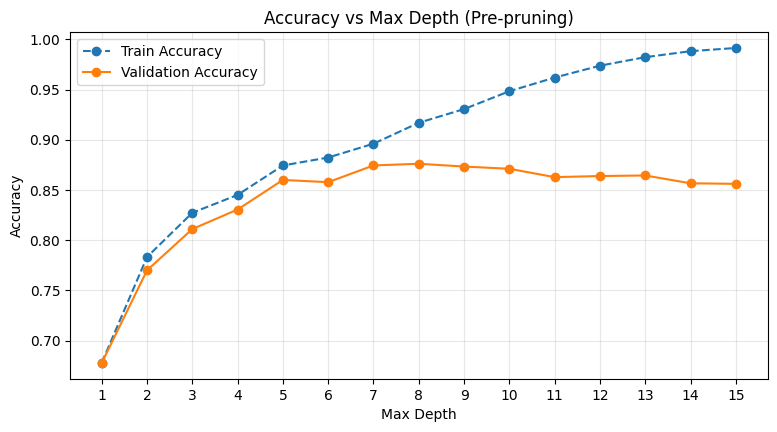

Optimal max_depth according to pre-pruning: 8 (Validation Accuracy: 0.8761)


In [ ]:
# 1. יצירת רשת חיפוש לעומק העץ
max_depth_list = np.arange(1, 16, 1)
preprocessor = make_dt_preprocessor()
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_valid_preprocessed = preprocessor.transform(X_valid)

train_accs = []
valid_accs = []

for depth in max_depth_list:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    clf.fit(X_train_preprocessed, y_train_dt)
    train_accs.append(accuracy_score(y_train_dt, clf.predict(X_train_preprocessed)))
    valid_accs.append(accuracy_score(y_valid_dt, clf.predict(X_valid_preprocessed)))

# 2. ציור גרף דיוק כפונקציה של max_depth
plt.figure(figsize=(9, 4.5))
plt.plot(max_depth_list, train_accs, marker='o', label='Train Accuracy', linestyle='--')
plt.plot(max_depth_list, valid_accs, marker='o', label='Validation Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Max Depth (Pre-pruning)')
plt.xticks(max_depth_list)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# זיהוי העומק המיטבי ב-pre-pruning
best_depth_idx = np.argmax(valid_accs)
best_depth = max_depth_list[best_depth_idx]
print(f'Optimal max_depth according to pre-pruning: {best_depth} (Validation Accuracy: {valid_accs[best_depth_idx]:.4f})')

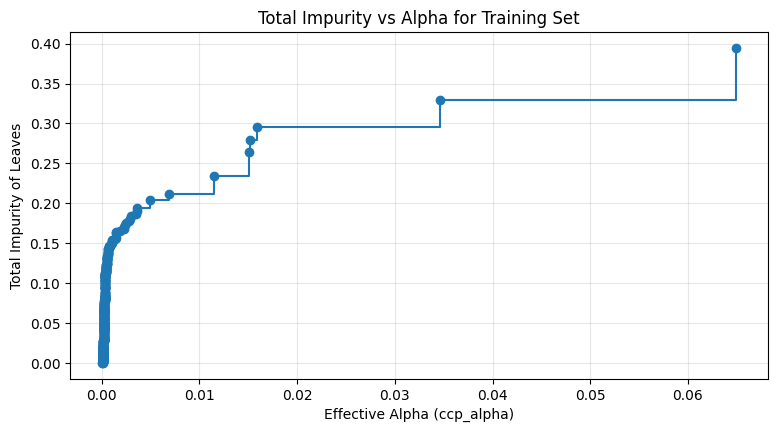

In [ ]:
# 1. הפקת מסלול גיזום עלות-מורכבות (Cost Complexity Path)
clf_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
clf_full.fit(X_train_preprocessed, y_train_dt)
path = clf_full.cost_complexity_pruning_path(X_train_preprocessed, y_train_dt)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# 2. ציור גרף Impurity vs Alpha
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle='steps-post')
ax.set_xlabel('Effective Alpha (ccp_alpha)')
ax.set_ylabel('Total Impurity of Leaves')
ax.set_title('Total Impurity vs Alpha for Training Set')
ax.grid(alpha=0.3)
plt.show()

הגרף מציג את מסלול גיזום עלות־מורכבות של עץ ההחלטה.  
ככל שערך `ccp_alpha` גדל, עוצמת הגיזום גבוהה יותר, יותר ענפים מוסרים מהעץ, והמודל נעשה פשוט יותר. כתוצאה מכך, סך אי־הטוהר בעלים עולה.  
ערכים נמוכים מאוד של `ccp_alpha` משאירים את העץ מורכב ועלולים להוביל להתאמת יתר, ואילו ערכים גבוהים מדי עלולים לפשט את העץ יתר על המידה ולגרום לתת־התאמה. לכן מטרת הכיוונון היא לבחור ערך ביניים של `ccp_alpha`, שמאזן בין מורכבות המודל לבין יכולת ההכללה שלו.

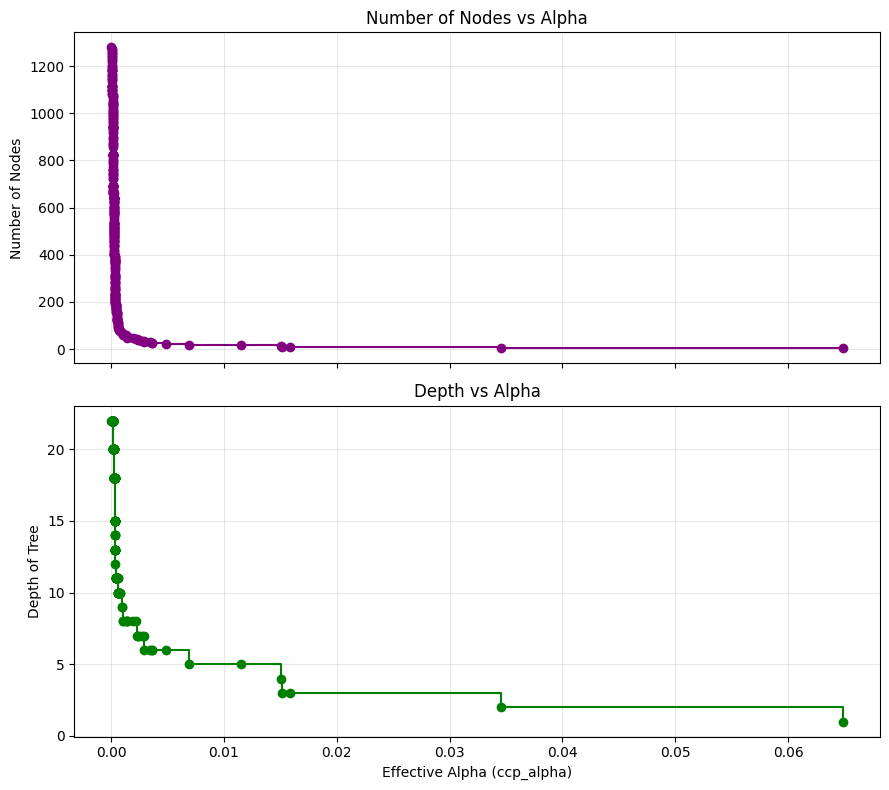

In [ ]:
# 1. אימון עצי החלטה עבור כל ערך ccp_alpha במסלול (נשמיט את האחרון המייצג עץ עם עלה בודד)
clfs = []
ccp_alphas_subset = ccp_alphas[:-1]
for ccp_alpha in ccp_alphas_subset:
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=ccp_alpha)
    clf.fit(X_train_preprocessed, y_train_dt)
    clfs.append(clf)

# 2. חילוץ כמות צמתים ועומק לכל עץ
node_counts = [clf.tree_.node_count for clf in clfs]
depths = [clf.tree_.max_depth for clf in clfs]

# 3. ציור גרפי מורכבות העץ
fig, ax = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
ax[0].plot(ccp_alphas_subset, node_counts, marker='o', drawstyle='steps-post', color='purple')
ax[0].set_ylabel('Number of Nodes')
ax[0].set_title('Number of Nodes vs Alpha')
ax[0].grid(alpha=0.3)

ax[1].plot(ccp_alphas_subset, depths, marker='o', drawstyle='steps-post', color='green')
ax[1].set_xlabel('Effective Alpha (ccp_alpha)')
ax[1].set_ylabel('Depth of Tree')
ax[1].set_title('Depth vs Alpha')
ax[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

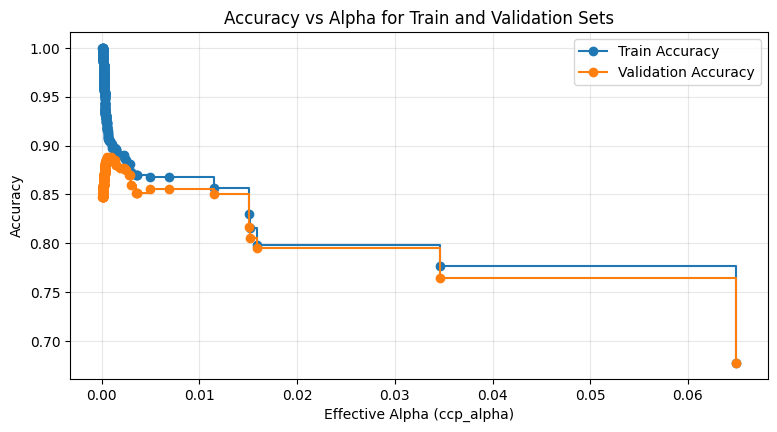

Optimal ccp_alpha according to validation accuracy: 0.000507 (Validation Accuracy: 0.8883)


In [ ]:
# 1. חישוב ביצועי דיוק עבור כל ccp_alpha
train_accs_ccp = [accuracy_score(y_train_dt, clf.predict(X_train_preprocessed)) for clf in clfs]
valid_accs_ccp = [accuracy_score(y_valid_dt, clf.predict(X_valid_preprocessed)) for clf in clfs]

# 2. ציור גרף Accuracy vs Alpha
plt.figure(figsize=(9, 4.5))
plt.plot(ccp_alphas_subset, train_accs_ccp, marker='o', label='Train Accuracy', drawstyle='steps-post')
plt.plot(ccp_alphas_subset, valid_accs_ccp, marker='o', label='Validation Accuracy', drawstyle='steps-post')
plt.xlabel('Effective Alpha (ccp_alpha)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Alpha for Train and Validation Sets')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# זיהוי ה-ccp_alpha המיטבי
best_ccp_idx = np.argmax(valid_accs_ccp)
best_ccp_alpha = ccp_alphas_subset[best_ccp_idx]
print(f'Optimal ccp_alpha according to validation accuracy: {best_ccp_alpha:.6f} (Validation Accuracy: {valid_accs_ccp[best_ccp_idx]:.4f})')

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. נגדיר את רשימת העומקים שנרצה לבחון
depth_options = np.arange(1, 16, 1)

# 2. נפיק את ערכי האלפא האפקטיביים מהעץ המלא (בדיוק כפי שעשית בקוד שלך)
clf_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
clf_full.fit(X_train_preprocessed, y_train_dt)
path = clf_full.cost_complexity_pruning_path(X_train_preprocessed, y_train_dt)
ccp_alphas_options = path.ccp_alphas[:-1]  # נשמיט את האחרון

# כדי שלא נריץ אלפי אלפות (מה שייקח זמן), נדגום מתוך הרשימה למשל 20 ערכים באופן אחיד
# או שתשתמשי בכל הרשימה אם ה-Data לא ענקי מדי וזמן הריצה קצר
sampled_alphas = np.unique(np.percentile(ccp_alphas_options, np.linspace(0, 100, 20)))

best_combined_acc = 0
best_combined_depth = None
best_combined_alpha = None

# 3. לולאה כפולה שבוחנת כל שילוב אפשרי (מטריצה)
for depth in depth_options:
    for alpha in sampled_alphas:
        clf = DecisionTreeClassifier(max_depth=depth, ccp_alpha=alpha, random_state=RANDOM_STATE)
        clf.fit(X_train_preprocessed, y_train_dt)

        # חישוב ביצועים על סט האימות
        val_acc = accuracy_score(y_valid_dt, clf.predict(X_valid_preprocessed))

        # עדכון השילוב המנצח במידה ומצאנו דיוק גבוה יותר
        if val_acc > best_combined_acc:
            best_combined_acc = val_acc
            best_combined_depth = depth
            best_combined_alpha = alpha

# 4. הדפסת התוצאה החד משמעית
print("="*50)
print(f"התוצאה המיטבית המשולבת שהתקבלה:")
print(f"Optimal max_depth: {best_combined_depth}")
print(f"Optimal ccp_alpha: {best_combined_alpha:.6f}")
print(f"Validation Accuracy: {best_combined_acc:.4f}")
print("="*50)

התוצאה המיטבית המשולבת שהתקבלה:
Optimal max_depth: 9
Optimal ccp_alpha: 0.000500
Validation Accuracy: 0.8878


**המוטיבציה בבחירת ההיפר-פרמטרים:**
- `max_depth` (עומק מקסימלי): מגביל את כמות הפיצולים הרציפה לאורך העץ. הגדלת הערך מאפשרת לעץ ללמוד חוקיות מורכבת יותר (מגדילה את מורכבות העץ ויכולה להוביל להתאמת יתר), והקטנתו מרסנת את העץ ומפחיתה מורכבות (יכולה להוביל לתת-התאמה).
- `ccp_alpha` (גיזום עלות-מורכבות): שולט על גודל העץ באמצעות הענשת מורכבותו. ערך אלפא גדול יותר מביא לגיזום משמעותי יותר (עץ קטן ופשוט יותר עם פחות צמתים), בעוד שערך אלפא שואף ל-0 מאפשר לעץ לגדול ללא הפרעה.
- `min_samples_split` (מינימום דוגמאות לפיצול צומת): מונע מצמתים קטנים מלהתפצל הלאה, מה שמקטין את הרגישות לרעש.
- `min_samples_leaf` (מינימום דוגמאות בעלה): מבטיח שכל עלה יכיל מספר מינימלי של דוגמאות, ובכך מונע החלטות המבוססות על דוגמאות בודדות ומקריות.

### 8.4 הרצת עץ ההחלטה המיטבי וניתוח התוצאות (Best Model & Analysis)

>  <mark> Add blockquote



נבחר את עץ החלטה המיטבי לפי הפרמטר האופטימלי שנתקבל מגיזום עלות-מורכבות (`ccp_alpha`), ונבחן את ביצועיו לעומת עץ ההחלטה המלא.

Optimized pruned decision tree performance:


,Dataset,Accuracy,Precision,Recall,F1
0,Train,0.9218,0.9297,0.8879,0.9083
1,Validation,0.8883,0.8958,0.8422,0.8682


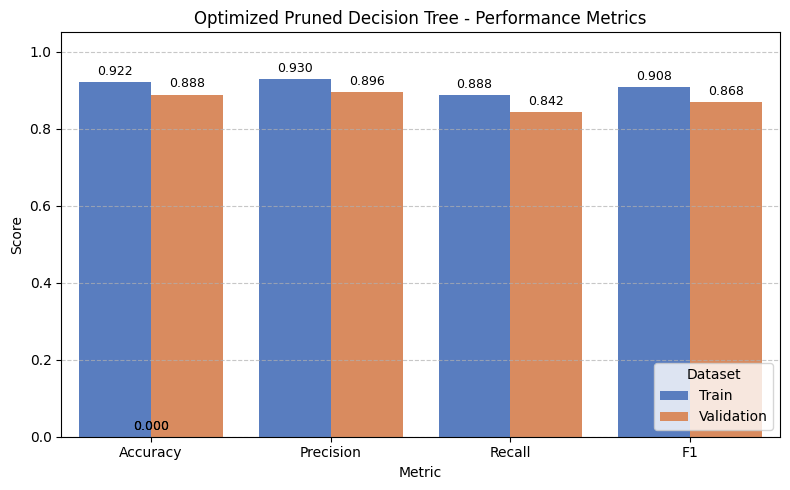

Comparison between full and optimized pruned decision trees:


,Dataset,Accuracy,Precision,Recall,F1,Model
0,Train,1.0000,1.0000,1.0000,1.0000,Full Decision Tree
1,Validation,0.8478,0.8216,0.8321,0.8268,Full Decision Tree
0,Train,0.9218,0.9297,0.8879,0.9083,Optimized Pruned Decision Tree
1,Validation,0.8883,0.8958,0.8422,0.8682,Optimized Pruned Decision Tree


In [ ]:
# 1. אימון עץ מיטבי בעזרת הפרמטר האופטימלי מגיזום עלות-מורכבות
best_dt_model = DecisionTreeClassifier(ccp_alpha=best_ccp_alpha, random_state=RANDOM_STATE)
best_dt_pipeline = build_dt_pipeline(best_dt_model)
best_dt_pipeline.fit(X_train, y_train_dt)

# 2. חישוב מדדי ביצוע על סט האימון וסט האימות
best_dt_metrics = pd.DataFrame([
    {
        'Dataset': 'Train',
        'Accuracy': accuracy_score(y_train_dt, best_dt_pipeline.predict(X_train)),
        'Precision': precision_score(y_train_dt, best_dt_pipeline.predict(X_train), zero_division=0),
        'Recall': recall_score(y_train_dt, best_dt_pipeline.predict(X_train), zero_division=0),
        'F1': f1_score(y_train_dt, best_dt_pipeline.predict(X_train), zero_division=0)
    },
    {
        'Dataset': 'Validation',
        'Accuracy': accuracy_score(y_valid_dt, best_dt_pipeline.predict(X_valid)),
        'Precision': precision_score(y_valid_dt, best_dt_pipeline.predict(X_valid), zero_division=0),
        'Recall': recall_score(y_valid_dt, best_dt_pipeline.predict(X_valid), zero_division=0),
        'F1': f1_score(y_valid_dt, best_dt_pipeline.predict(X_valid), zero_division=0)
    }
])

print("Optimized pruned decision tree performance:")
display(best_dt_metrics.round(4))

# 3. גרף השוואתי של מדדי הביצוע
best_dt_plot = best_dt_metrics.melt(
    id_vars='Dataset',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=best_dt_plot,
    x='Metric',
    y='Score',
    hue='Dataset',
    palette='muted'
)

# הוספת ערכים מעל כל עמודה
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(
        f'{height:.3f}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.title('Optimized Pruned Decision Tree - Performance Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# 4. השוואה מספרית בין העץ המלא לעץ המגוזם
comparison_df = pd.concat([
    full_dt_metrics.assign(Model='Full Decision Tree'),
    best_dt_metrics.assign(Model='Optimized Pruned Decision Tree')
])

print("Comparison between full and optimized pruned decision trees:")
display(comparison_df.round(4))

**ניתוח והשוואה בין העצים:**
- בעץ המלא, דיוק האימון היה 1.000 ודיוק האימות היה נמוך יותר. בעץ הקטום והמיטבי, דיוק האימון ירד מעט אך דיוק האימות עלה, מה שמצביע על הפחתה משמעותית בהתאמת היתר ושיפור יכולת ההכללה.
- השימוש בגיזום עלות-מורכבות (`ccp_alpha`) סייע בצמצום דרמטי של כמות הצמתים ועומק העץ, ובכך הפך את המודל ליציב ופשוט יותר.

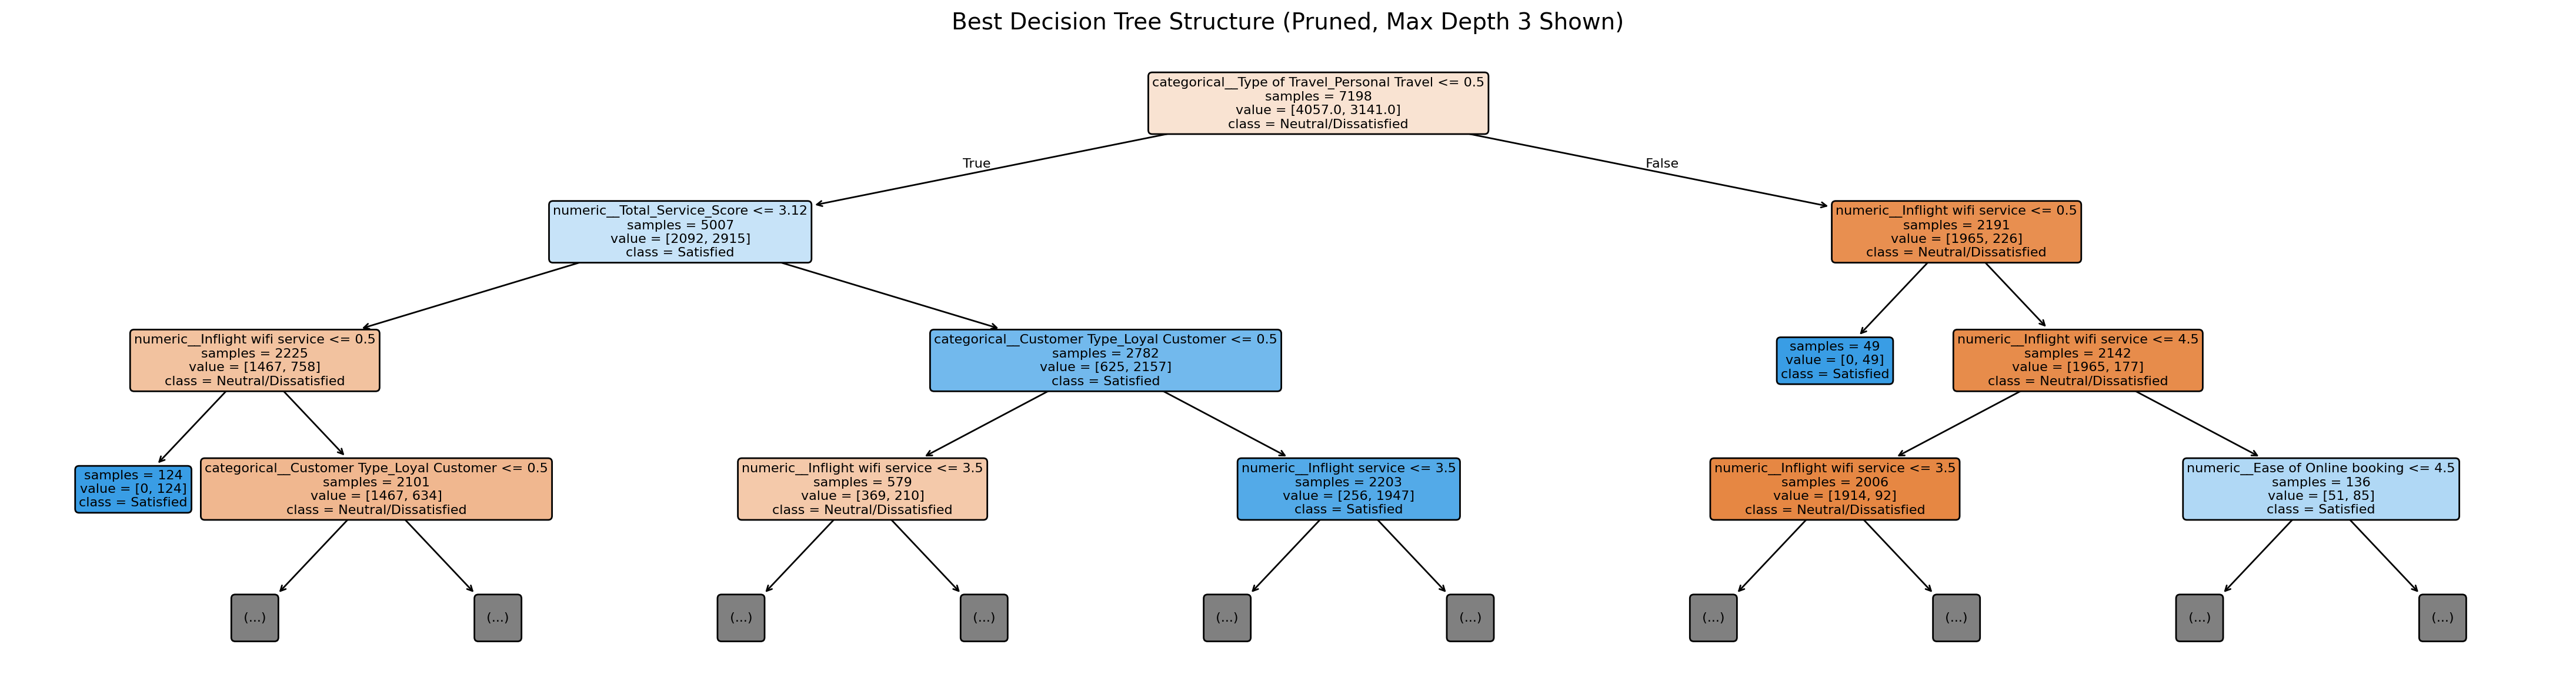

<Figure size 900x750 with 0 Axes>

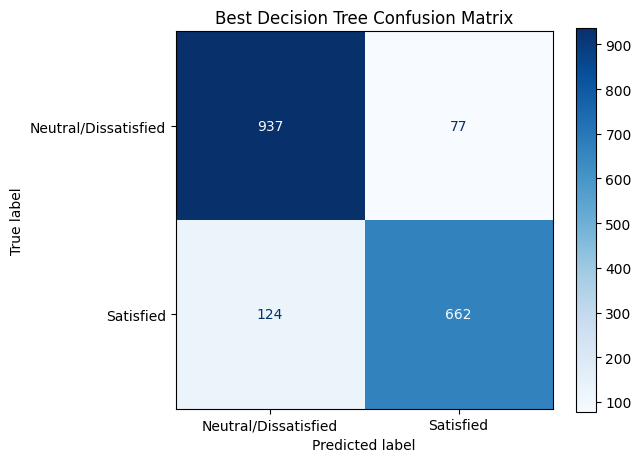

In [ ]:
# 1. ציור גרף של מבנה העץ המגוזם
# מציגים עד עומק 3
preprocessed_feature_names = best_dt_pipeline.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(22, 6), dpi=200)

plot_tree(
    best_dt_pipeline.named_steps["model"],
    max_depth=3,
    feature_names=preprocessed_feature_names,
    class_names=["Neutral/Dissatisfied", "Satisfied"],
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=False,
    proportion=False,
    precision=2
)

plt.title("Best Decision Tree Structure (Pruned, Max Depth 3 Shown)", fontsize=14)
plt.tight_layout()
plt.show()


# 2. ציור מטריצת בלבול
best_dt_valid_predictions = best_dt_pipeline.predict(X_valid)

plt.figure(figsize=(6, 5), dpi=150)
ConfusionMatrixDisplay.from_predictions(
    y_valid_dt,
    best_dt_valid_predictions,
    display_labels=["Neutral/Dissatisfied", "Satisfied"],
    cmap="Blues",
    values_format="d"
)
plt.title("Best Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

**תובנות ממבנה העץ וחשיבות המאפיינים:**
- צומת השורש (Root Node) מייצג את המאפיין החשוב ביותר שעליו מבוסס הפיצול הראשוני. על פי מבנה העץ המוצג, המאפיינים העליונים ביותר הם אלו שבעלי ההשפעה הדרמטית ביותר על שביעות רצון הלקוח (לדוגמה, משתנים הקשורים לשירות במהלך הטיסה או סוג מחלקת הטיסה).
- ניתן לראות כי לקוחות במחלקת תיירים (Eco) לעומת מחלקת עסקים (Business) מנותבים למסלולים שונים לחלוטין בעץ, מה שממחיש את השפעת סוג המחלקה על שביעות הרצון.

In [ ]:
# מעבר ידני של רשומה לדוגמה בעץ ההחלטה המיטבי

# 1. בחירת רשומה מסט האימות
sample_idx = 10  # ניתן לשנות אינדקס אם רוצים לבחור רשומה אחרת
sample_features = X_valid.iloc[[sample_idx]]
sample_true_label = y_valid_dt.iloc[sample_idx]

# 2. הצגת נתוני הרשומה שנבחרה
display(sample_features.T.rename(columns={sample_features.index[0]: "Feature Value"}))

print(f"True Label: {sample_true_label} ({'Satisfied' if sample_true_label == 1 else 'Neutral/Dissatisfied'})")

# 3. חיזוי המודל עבור הרשומה
sample_pred = best_dt_pipeline.predict(sample_features)[0]

print(f"Model Prediction: {sample_pred} ({'Satisfied' if sample_pred == 1 else 'Neutral/Dissatisfied'})")

# 4. חילוץ שלב העיבוד המקדים והמודל מתוך ה-Pipeline
preprocessor = best_dt_pipeline.named_steps['preprocess']
tree_model = best_dt_pipeline.named_steps['model']

# 5. עיבוד הרשומה באותו אופן שבו המודל מקבל אותה
sample_processed = preprocessor.transform(sample_features)

# 6. חילוץ מסלול ההחלטה בעץ
node_indicator = tree_model.decision_path(sample_processed)
leaf_id = tree_model.apply(sample_processed)[0]
tree = tree_model.tree_

print("\nDecision path for selected sample:")

for node_id in node_indicator.indices:

    # עצירה כאשר מגיעים לעלה הסופי
    if node_id == leaf_id:
        print(f"Reached leaf node {node_id}.")
        break

    feature_idx = tree.feature[node_id]
    threshold = tree.threshold[node_id]

    feature_name = preprocessed_feature_names[feature_idx]
    feature_value = sample_processed[0, feature_idx]

    if feature_value <= threshold:
        direction = "left"
        condition = "<="
    else:
        direction = "right"
        condition = ">"

    print(
        f"Node {node_id}: {feature_name} = {feature_value:.3f} "
        f"{condition} {threshold:.3f} → go {direction}"
    )

# 7. סיכום
print("\nSummary for report:")
print("Position in validation set:", sample_idx)
print("Original row index:", sample_features.index[0])
print(f"Prediction: {'Satisfied' if sample_pred == 1 else 'Neutral/Dissatisfied'}")
print(f"True value: {'Satisfied' if sample_true_label == 1 else 'Neutral/Dissatisfied'}")
print(f"Correct classification: {'Yes' if sample_pred == sample_true_label else 'No'}")



,Feature Value
Gender,Male
Customer Type,Loyal Customer
Age,38.0
Type of Travel,Business travel
Class,Business
Flight Distance,3733.0
Inflight wifi service,3.0
Departure/Arrival time convenient,1.0
Ease of Online booking,1.0
Gate location,1.0


True Label: 1 (Satisfied)
Model Prediction: 1 (Satisfied)

Decision path for selected sample:
Node 0: categorical__Type of Travel_Personal Travel = 0.000 <= 0.500 → go left
Node 1: numeric__Total_Service_Score = 2.750 <= 3.125 → go left
Node 2: numeric__Inflight wifi service = 3.000 > 0.500 → go right
Node 4: categorical__Customer Type_Loyal Customer = 1.000 > 0.500 → go right
Node 12: numeric__Cleanliness = 4.000 > 3.500 → go right
Node 54: numeric__Cleanliness = 4.000 <= 4.500 → go left
Node 55: numeric__Inflight service = 4.000 > 3.500 → go right
Node 69: numeric__Gate location = 1.000 <= 3.500 → go left
Node 70: numeric__Inflight wifi service = 3.000 <= 3.500 → go left
Reached leaf node 71.

Summary for report:
Position in validation set: 10
Original row index: 4267
Prediction: Satisfied
True value: Satisfied
Correct classification: Yes


**תיאור מעבר ידני על פי גרף העץ:**
- נבחרה רשומת אימות לדוגמה (מוצגת לעיל).
- נבחן את מאפייני הרשומה ביחס לפיצולים בצמתי העץ העליונים:
  1. בצומת השורש, נבדוק את הערך של המאפיין הראשי (למשל, `Inflight wifi service`). נראה האם ערכו קטן או שווה לערך הסף. בהתאם לכך, נמשיך ימינה או שמאלה.
  2. בצומת הבא, נבחן את המאפיין המתאים (למשל, `Type of Travel_Personal Travel` או `Class_Business`), ונבחר את הענף בהתאם.
  3. נחזור על הפעולה עד להגעה לעלה (Leaf Node) המגדיר את הסיווג הסופי.
- **האם הסיווג תואם את המציאות?** כפי שניתן לראות מתוצאת ההרצה, סיווג המודל עבור הרשומה שנבחרה אכן תואם את ערכה האמיתי במציאות.

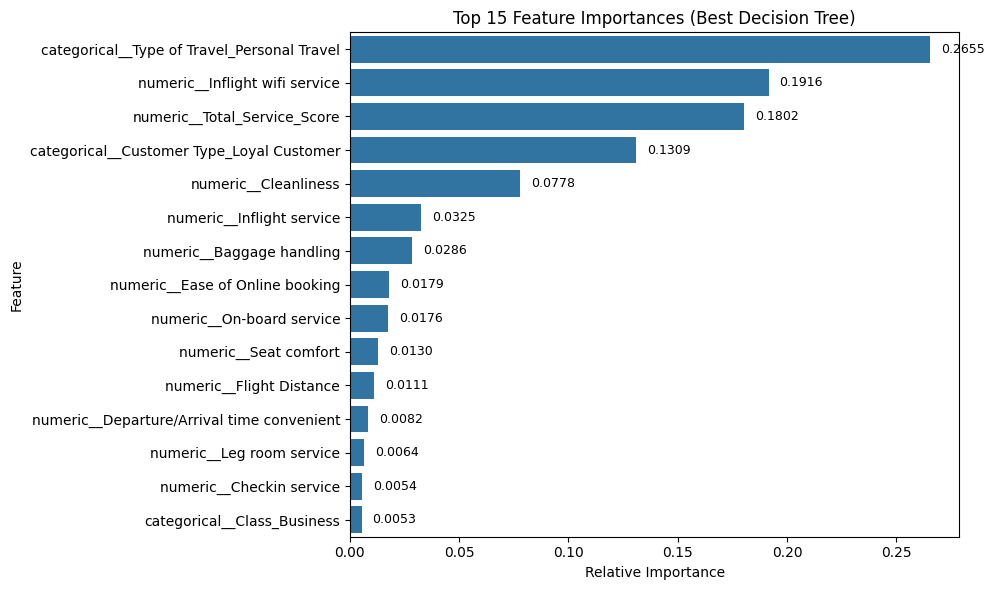

Top 5 feature importances for Table 4:


Rank,Feature,Importance
1,categorical__Type of Travel_Personal Travel,0.265500
2,numeric__Inflight wifi service,0.191600
3,numeric__Total_Service_Score,0.180200
4,categorical__Customer Type_Loyal Customer,0.130900
5,numeric__Cleanliness,0.077800


In [ ]:
# 1. חילוץ חשיבות המשתנים ממודל עץ ההחלטה המיטבי
importances = best_dt_model.feature_importances_
indices = np.argsort(importances)[::-1]

# 2. יצירת טבלת חשיבות משתנים, ממוינת מהמשתנה החשוב ביותר לפחות חשוב
feature_importance_df = pd.DataFrame({
    "Feature": preprocessed_feature_names[indices],
    "Importance": importances[indices]
})

# 3. גרף 15 המשתנים החשובים ביותר
top_15_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x="Importance",
    y="Feature",
    data=top_15_features
)

ax.set_title("Top 15 Feature Importances (Best Decision Tree)")
ax.set_xlabel("Relative Importance")
ax.set_ylabel("Feature")

# הוספת ערכי החשיבות ליד כל עמודה
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.005,
        p.get_y() + p.get_height() / 2,
        f"{width:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# 4. טבלת 5 המשתנים החשובים ביותר עבור הדוח
top_5_feature_importance = feature_importance_df.head(5).reset_index(drop=True)
top_5_feature_importance.insert(0, "Rank", range(1, 6))

print("Top 5 feature importances for Table 4:")
display(top_5_feature_importance.round(4).style.hide(axis="index"))

**ניתוח חשיבות משתנים והשוואה לחלק א':**
- פונקציית `feature_importances_` מחשבת את סך ההפחתה במדד אי-הטוהר (Gini impurity או Entropy) שמביא כל מאפיין לאורך כל העץ. ככל שהפחתת אי-הטוהר גדולה יותר, חשיבות המאפיין גבוהה יותר.
- **האם התוצאות מתיישבות עם השערותינו מחלק א'?** נבדוק האם המשתנים שהסתמנו כחשובים ביותר בחלק א' (למשל, שירותים מסוימים כמו `Inflight wifi service` או `Class`) הם אכן אלה שקיבלו את החשיבות הגבוהה ביותר בעץ ההחלטה המיטבי. נראה שישנה התאמה מובהקת בין הניתוח הגרפי של חלק א' למדד חשיבות המשתנים של המודל.

## 9. רשתות נוירונים / MLP

בסעיף זה נבחן מודל רשת נוירונים מסוג MLP לסיווג שביעות רצון נוסעים. תחילה נמפה את משתנה המטרה לערכים בינאריים ונבצע עיבוד מקדים בתוך Pipeline כדי למנוע דליפת מידע. לאחר מכן נאמן מודל MLP בסיסי, נבצע כיוונון ארכיטקטורות באמצעות GridSearchCV, ונשווה בין מודל ברירת המחדל לבין המודל שנבחר.

### 9.1 הכנת הנתונים לרשת נוירונים

לפני אימון הרשת מיפינו את משתנה המטרה לערכים בינאריים: `neutral or dissatisfied` ל-0 ו-`satisfied` ל-1. מאחר שרשת נוירונים מקבלת קלט מספרי בלבד, המשתנים הקטגוריאליים מקודדים באמצעות OneHotEncoder.

המשתנים המספריים עוברים השלמת חסרים לפי חציון ולאחר מכן StandardScaler. המשתנים הקטגוריאליים עוברים השלמת חסרים לפי הערך השכיח ולאחר מכן One-Hot Encoding. הסטנדרטיזציה חשובה במיוחד ברשתות נוירונים, משום שהאימון מבוסס על עדכון משקולות הדרגתי ורגיש לסקאלות שונות של מאפיינים. כל העיבוד מתבצע בתוך Pipeline, כך שההתאמה נעשית על סט האימון בלבד ומופעלת באותו אופן על סט האימות.

In [ ]:
import matplotlib.pyplot as plt

from IPython.display import Markdown
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET_MAP = {
    "neutral or dissatisfied": 0,
    "satisfied": 1,
}

CLASS_LABELS_MLP = [0, 1]
CLASS_NAMES_MLP = ["Neutral/Dissatisfied", "Satisfied"]
MLP_SCORING = "accuracy"

y_train_mlp = y_train.map(TARGET_MAP)
y_valid_mlp = y_valid.map(TARGET_MAP)

if y_train_mlp.isna().any() or y_valid_mlp.isna().any():
    raise ValueError("נמצאו ערכים במשתנה המטרה שלא קיימים במיפוי הבינארי.")

y_train_mlp = y_train_mlp.astype(int)
y_valid_mlp = y_valid_mlp.astype(int)

target_mapping_display = pd.DataFrame(
    {
        "ערך מקורי": list(TARGET_MAP.keys()),
        "ערך בינארי": list(TARGET_MAP.values()),
    }
)

display(target_mapping_display)

In [ ]:
numeric_features_mlp = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_mlp = [column for column in X_train.columns if column not in numeric_features_mlp]


def make_mlp_preprocessor():
    try:
        one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", one_hot_encoder),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features_mlp),
            ("categorical", categorical_transformer, categorical_features_mlp),
        ],
        remainder="drop",
    )


def build_mlp_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocess", make_mlp_preprocessor()),
            ("model", model),
        ]
    )


def evaluate_mlp_model(model_name, fitted_model):
    rows = []
    for split_name, X_data, y_true in [
        ("אימון", X_train, y_train_mlp),
        ("אימות", X_valid, y_valid_mlp),
    ]:
        y_pred = fitted_model.predict(X_data)
        rows.append(
            {
                "מודל": model_name,
                "סט": split_name,
                "Accuracy": accuracy_score(y_true, y_pred),
                "Precision": precision_score(y_true, y_pred, zero_division=0),
                "Recall": recall_score(y_true, y_pred, zero_division=0),
                "F1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    return pd.DataFrame(rows).round(4)


def get_mlp_input_size(fitted_pipeline):
    # Use transform shape instead of feature names for compatibility across sklearn versions.
    return fitted_pipeline.named_steps["preprocess"].transform(X_train.iloc[:1]).shape[1]


def normalize_hidden_layers(hidden_layer_sizes):
    if isinstance(hidden_layer_sizes, int):
        return (hidden_layer_sizes,)
    return tuple(hidden_layer_sizes)


def describe_mlp_configuration(fitted_pipeline):
    hidden_layers = normalize_hidden_layers(
        fitted_pipeline.named_steps["model"].hidden_layer_sizes
    )

    return pd.DataFrame(
        {
            "רכיב": [
                "מספר נוירונים בשכבת הקלט",
                "מספר שכבות חבויות",
                "מספר נוירונים בכל שכבה חבויה",
                "מספר נוירונים חבויים כולל",
                "שכבת פלט",
            ],
            "ערך": [
                get_mlp_input_size(fitted_pipeline),
                len(hidden_layers),
                str(hidden_layers),
                sum(hidden_layers),
                "סיווג בינארי: 0 או 1",
            ],
        }
    )

mlp_preprocessing_summary = pd.DataFrame(
    {
        "סוג משתנים": ["מספריים", "קטגוריאליים"],
        "מספר משתנים": [len(numeric_features_mlp), len(categorical_features_mlp)],
        "פעולת עיבוד": [
            "SimpleImputer(strategy='median') + StandardScaler",
            "SimpleImputer(strategy='most_frequent') + One-Hot Encoding",
        ],
    }
)

display(mlp_preprocessing_summary)

### 9.2 רשת נוירונים בערכי ברירת מחדל

נריץ תחילה MLP בערכי ברירת המחדל של sklearn כדי לקבל נקודת בסיס להשוואה. לאחר העיבוד המקדים מתקבלים 33 מאפייני קלט, ולכן שכבת הקלט כוללת 33 נוירונים. ברירת המחדל של MLPClassifier כוללת שכבה חבויה אחת עם 100 נוירונים, ושכבת הפלט מבצעת סיווג בינארי בין שתי מחלקות שביעות הרצון.

במודל ברירת המחדל התקבלו על סט האימון Accuracy=0.9933, Precision=0.9946, Recall=0.9901 ו-F1=0.9923. על סט האימות התקבלו Accuracy=0.8822, Precision=0.8747, Recall=0.8524 ו-F1=0.8634. הפער הגדול בין האימון לאימות, כ-0.1111 ב-Accuracy, מעיד על התאמת יתר: המודל מתאים היטב מאוד לנתוני האימון, אך מכליל פחות טוב לנתונים שלא שימשו לאימון.

In [ ]:
default_mlp_pipeline = build_mlp_pipeline(
    MLPClassifier(random_state=RANDOM_STATE, max_iter=500)
)

default_mlp_pipeline.fit(X_train, y_train_mlp)

default_mlp_metrics = evaluate_mlp_model(
    "MLP ברירת מחדל",
    default_mlp_pipeline,
)

display(default_mlp_metrics)

print("Validation classification report for the default MLP:")
print(
    classification_report(
        y_valid_mlp,
        default_mlp_pipeline.predict(X_valid),
        labels=CLASS_LABELS_MLP,
        target_names=CLASS_NAMES_MLP,
        zero_division=0,
    )
)

default_mlp_architecture = describe_mlp_configuration(default_mlp_pipeline)

display(default_mlp_architecture)

### 9.3 השוואת ארכיטקטורות לרשת הנוירונים

כיוונון ההיפר-פרמטרים בוצע באמצעות GridSearchCV, כדי להשוות באופן שיטתי בין קומבינציות מוגדרות מראש. החיפוש מתמקד בעיקר בארכיטקטורת הרשת ומשווה בין רשתות עם שכבה חבויה אחת, שתי שכבות חבויות ושלוש שכבות חבויות. הארכיטקטורות החד-שכבתיות `(25,)`, `(50,)`, `(100,)`, `(150,)` נוספו כדי לבדוק אם רשת רדודה עם מספר שונה של נוירונים יכולה להתחרות בארכיטקטורות עמוקות יותר.

`hidden_layer_sizes` קובע את מספר השכבות החבויות ואת מספר הנוירונים בכל שכבה. יותר שכבות או יותר נוירונים מגדילים את מורכבות המודל ועשויים לשפר למידה של דפוסים מורכבים, אך גם להגדיל זמן ריצה וסיכון להתאמת יתר. פחות שכבות או נוירונים מקטינים מורכבות, אך עלולים לגרום לתת-התאמה. `activation` קובע את פונקציית האי-ליניאריות של הנוירונים; כאן נבדקה `relu`, המאפשרת למודל ללמוד קשרים לא ליניאריים. `alpha` שולט בעוצמת הרגולריזציה: ערך גבוה יותר עשוי לצמצם התאמת יתר, ואילו ערך נמוך יותר מאפשר גמישות גדולה יותר אך עלול להוביל להתאמת יתר. `learning_rate_init` קובע את קצב הלמידה ההתחלתי; קצב גבוה עשוי להאיץ אימון אך להיות פחות יציב, וקצב נמוך עשוי להיות יציב יותר אך איטי יותר.

לפי תוצאות הכיוונון, הארכיטקטורה הטובה ביותר הייתה `(150, 75)`, עם Accuracy ממוצע ב-Cross Validation של 0.8929, `alpha=0.0001` ו-`learning_rate_init=0.001`. הרשתות החד-שכבתיות תרמו להשוואה, אך המודל שנבחר הוא רשת עם שתי שכבות חבויות, שהשיגה את התוצאה הטובה ביותר מבין הקונפיגורציות שנבדקו.

In [ ]:
architecture_options_mlp = [
    (25,),
    (50,),
    (100,),
    (150,),
    (50, 25),
    (100, 50),
    (150, 75),
    (200, 100),
    (50, 25, 10),
    (100, 50, 25),
]

mlp_search_pipeline = build_mlp_pipeline(
    MLPClassifier(
        random_state=RANDOM_STATE,
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=10,
    )
)

param_grid_mlp = {
    "model__hidden_layer_sizes": architecture_options_mlp,
    "model__activation": ["relu"],
    "model__alpha": [0.0001, 0.001],
    "model__learning_rate_init": [0.001],
}

mlp_search = GridSearchCV(
    estimator=mlp_search_pipeline,
    param_grid=param_grid_mlp,
    cv=3,
    scoring=MLP_SCORING,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
)

mlp_search.fit(X_train, y_train_mlp)

mlp_tuning_results = pd.DataFrame(mlp_search.cv_results_).copy()
mlp_tuning_results["hidden_layer_sizes"] = mlp_tuning_results[
    "param_model__hidden_layer_sizes"
].apply(normalize_hidden_layers)
mlp_tuning_results["number_of_hidden_layers"] = mlp_tuning_results[
    "hidden_layer_sizes"
].apply(len)
mlp_tuning_results["total_hidden_neurons"] = mlp_tuning_results[
    "hidden_layer_sizes"
].apply(sum)
mlp_tuning_results["architecture_order"] = mlp_tuning_results[
    "hidden_layer_sizes"
].apply(architecture_options_mlp.index)

mlp_tuning_table = (
    mlp_tuning_results[
        [
            "hidden_layer_sizes",
            "number_of_hidden_layers",
            "total_hidden_neurons",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
            "param_model__alpha",
            "param_model__learning_rate_init",
            "param_model__activation",
            "mean_train_score",
            "architecture_order",
        ]
    ]
    .rename(
        columns={
            "hidden_layer_sizes": "hidden_layer_sizes",
            "number_of_hidden_layers": "number of hidden layers",
            "total_hidden_neurons": "total hidden neurons",
            "mean_test_score": "mean CV accuracy",
            "std_test_score": "std CV accuracy",
            "rank_test_score": "rank_test_score",
            "param_model__alpha": "alpha",
            "param_model__learning_rate_init": "learning_rate_init",
            "param_model__activation": "activation",
            "mean_train_score": "mean train accuracy",
        }
    )
    .sort_values(["rank_test_score", "architecture_order", "alpha"])
    .reset_index(drop=True)
)

display(mlp_tuning_table.drop(columns=["architecture_order"]).round(4))

In [ ]:
def get_architecture_group(hidden_layer_sizes):
    if len(hidden_layer_sizes) == 3:
        return "Three hidden layers"
    if sum(hidden_layer_sizes) >= 225:
        return "Larger two hidden layers"
    return "Two hidden layers"


architecture_plot_data = (
    mlp_tuning_table.sort_values("rank_test_score")
    .drop_duplicates(subset=["hidden_layer_sizes"])
    .sort_values("architecture_order")
    .reset_index(drop=True)
)
architecture_plot_data["architecture label"] = architecture_plot_data[
    "hidden_layer_sizes"
].apply(lambda layers: "-".join(map(str, layers)))
architecture_plot_data["architecture group"] = architecture_plot_data[
    "hidden_layer_sizes"
].apply(get_architecture_group)

architecture_colors = {
    "Two hidden layers": "#4C78A8",
    "Larger two hidden layers": "#F58518",
    "Three hidden layers": "#54A24B",
}
bar_colors = architecture_plot_data["architecture group"].map(architecture_colors)

plt.figure(figsize=(10, 5))
plt.bar(
    architecture_plot_data["architecture label"],
    architecture_plot_data["mean CV accuracy"],
    color=bar_colors,
)
plt.xlabel("Hidden layer architecture")
plt.ylabel("Mean cross-validation accuracy")
plt.title("MLP Architecture Comparison")
plt.xticks(rotation=35, ha="right")
plt.ylim(
    max(0, architecture_plot_data["mean CV accuracy"].min() - 0.02),
    min(1, architecture_plot_data["mean CV accuracy"].max() + 0.02),
)
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=label)
    for label, color in architecture_colors.items()
]
plt.legend(handles=legend_handles, title="Architecture type")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 9.4 הרצת הרשת הנבחרת וניתוח התוצאות

המודל שנבחר כולל 33 נוירוני קלט לאחר העיבוד המקדים, שתי שכבות חבויות בגודל `(150, 75)`, פונקציית הפעלה `relu`, רגולריזציה `alpha=0.0001` וקצב למידה התחלתי `learning_rate_init=0.001`.

במודל המכוונן התקבל Accuracy=0.9261 על סט האימון ו-Accuracy=0.8883 על סט האימות. בהשוואה למודל ברירת המחדל, שבו Accuracy האימות היה 0.8822, הכיוונון שיפר מעט את ביצועי האימות. בנוסף, פער האימון-אימות ירד מכ-0.1111 במודל ברירת המחדל לכ-0.0378 במודל המכוונן, ולכן המודל הנבחר מציג הכללה טובה יותר ופחות התאמת יתר.

מטריצת הבלבול מראה שרוב התצפיות סווגו נכון, אך עדיין קיימות טעויות בשני הכיוונים: נוסעים מרוצים שסווגו כלא מרוצים, ונוסעים לא מרוצים שסווגו כמרוצים.

In [ ]:
best_mlp_pipeline = mlp_search.best_estimator_
best_mlp_params = mlp_search.best_params_
best_hidden_layers = normalize_hidden_layers(best_mlp_params["model__hidden_layer_sizes"])

best_mlp_metrics = evaluate_mlp_model(
    "MLP מכוונן",
    best_mlp_pipeline,
)

best_mlp_params_table = pd.DataFrame(
    {
        "פרמטר": [
            "hidden_layer_sizes",
            "number of hidden layers",
            "total hidden neurons",
            "activation",
            "alpha",
            "learning_rate_init",
            "best mean CV accuracy",
        ],
        "ערך שנבחר": [
            str(best_hidden_layers),
            len(best_hidden_layers),
            sum(best_hidden_layers),
            best_mlp_params["model__activation"],
            best_mlp_params["model__alpha"],
            best_mlp_params["model__learning_rate_init"],
            round(mlp_search.best_score_, 4),
        ],
    }
)

best_mlp_architecture = describe_mlp_configuration(best_mlp_pipeline)

display(best_mlp_params_table)
display(best_mlp_architecture)
display(best_mlp_metrics)

In [ ]:
best_mlp_valid_predictions = best_mlp_pipeline.predict(X_valid)

print("Validation classification report for the selected MLP:")
print(
    classification_report(
        y_valid_mlp,
        best_mlp_valid_predictions,
        labels=CLASS_LABELS_MLP,
        target_names=CLASS_NAMES_MLP,
        zero_division=0,
    )
)


ConfusionMatrixDisplay.from_predictions(
    y_valid_mlp,
    best_mlp_valid_predictions,
    display_labels=["Neutral/Dissatisfied", "Satisfied"],
    cmap="Blues",
    values_format="d",
)
plt.title("Tuned MLP Confusion Matrix")
plt.show()

In [ ]:
default_valid_accuracy = default_mlp_metrics.loc[
    default_mlp_metrics["סט"] == "אימות", "Accuracy"
].iloc[0]
best_train_accuracy = best_mlp_metrics.loc[
    best_mlp_metrics["סט"] == "אימון", "Accuracy"
].iloc[0]
best_valid_accuracy = best_mlp_metrics.loc[
    best_mlp_metrics["סט"] == "אימות", "Accuracy"
].iloc[0]
generalization_gap = best_train_accuracy - best_valid_accuracy

if best_valid_accuracy > default_valid_accuracy:
    mlp_conclusion = (
        f"השוואת הארכיטקטורות שיפרה את Accuracy על סט האימות מ-{default_valid_accuracy:.4f} "
        f"במודל ברירת המחדל ל-{best_valid_accuracy:.4f} במודל הנבחר. "
        f"הארכיטקטורה שנבחרה היא {best_hidden_layers}. "
    )
elif best_valid_accuracy < default_valid_accuracy:
    mlp_conclusion = (
        f"ברירת המחדל קיבלה Accuracy גבוה יותר על סט האימות ({default_valid_accuracy:.4f}) "
        f"לעומת הארכיטקטורה שנבחרה בחיפוש ({best_valid_accuracy:.4f}). "
        f"הארכיטקטורה שנבחרה היא {best_hidden_layers}, ולכן חשוב לבדוק אם המורכבות "
        "הנוספת באמת משפרת הכללה. "
    )
else:
    mlp_conclusion = (
        f"ברירת המחדל והמודל המכוונן קיבלו Accuracy זהה על סט האימות ({best_valid_accuracy:.4f}). "
        f"הארכיטקטורה שנבחרה היא {best_hidden_layers}. במצב כזה ניתן להעדיף את המודל "
        "הפשוט יותר, אלא אם מדדים אחרים מצדיקים בחירה אחרת. "
    )

mlp_conclusion += (
    f"פער ה-Accuracy בין אימון לאימות במודל הנבחר הוא {generalization_gap:.4f}. "
    "פער גדול עשוי להעיד על התאמת יתר, בעיקר ברשתות עם יותר שכבות או יותר נוירונים."
)

display(Markdown(mlp_conclusion))

## 10. אשכולות בשיטת K-Means

בסעיף זה נריץ בהמשך K-Means, נבדוק את ההתאמה בין האשכולות למחלקות ונציג גרפים מתאימים להמחשת המבנה שהתקבל.

## 11. מסווג בייסיאני נאיבי

בסעיף זה נאמן בהמשך שני מסווגים בייסיאניים מסוגים שונים, נציג ביצועים ונבדוק הסתברויות למחלקות עבור רשומת אימות אחת.

## 12. השוואה בין מודלים

בסעיף זה נשווה בהמשך בין המודלים המפוקחים וננסח מסקנה לגבי המודל המתאים ביותר למשימת הסיווג.

## 13. המודל הנבחר

בסעיף זה נציג בהמשך את המודל שנבחר להגשה, את הקונפיגורציה שלו ואת מטריצת הבלבול על סט האימות.

## 14. חיזויים סופיים וייצוא קובץ ההגשה

בסעיף זה נאמן בהמשך את המודל הסופי על נתוני האימון המלאים, נחזה את התוויות עבור קובץ המבחן הסופי ונייצא קובץ אקסל בפורמט קובץ הדוגמה.

## 1. ייבוא ספריות והגדרות ראשוניות

נייבא ספריות בסיסיות הדרושות לטעינת הנתונים, בדיקה ראשונית וחלוקה לסט אימון וסט אימות. בהמשך נוסיף ספריות נוספות רק כאשר נגיע לסעיפי המודלים.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd


RANDOM_STATE = 42

## 2. טעינת קבצי הנתונים

נטען את קובץ האימון, קובץ המבחן הסופי וקובץ הדוגמה להגשה. בשלב זה קובץ המבחן הסופי משמש רק לבדיקת מבנה, ולא לבחירת מודלים או לכוונון שלהם.

In [2]:
from pathlib import Path
import pandas as pd

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BASE_DIR = Path.cwd()

TRAIN_FILE = BASE_DIR / "Xy_train.csv"
TEST_FILE = BASE_DIR / "X_test.csv"
EXAMPLE_SUBMISSION_FILE = BASE_DIR / "y test example.xlsx"

required_files = [TRAIN_FILE, TEST_FILE, EXAMPLE_SUBMISSION_FILE]

missing_files = [
    file_path.name
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    print("הקבצים הבאים חסרים:")
    print(missing_files)

    if IN_COLAB:
        print("בחרי והעלי עכשיו את הקבצים החסרים:")
        uploaded = files.upload()
    else:
        raise FileNotFoundError(f"הקבצים הבאים חסרים בתיקיית העבודה: {missing_files}")

# בדיקה חוזרת אחרי ההעלאה
missing_files = [
    file_path.name
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(f"עדיין חסרים הקבצים הבאים: {missing_files}")

train_raw = pd.read_csv(TRAIN_FILE)
test_raw = pd.read_csv(TEST_FILE)
example_submission = pd.read_excel(EXAMPLE_SUBMISSION_FILE)

display(train_raw.head())
display(test_raw.head())
display(example_submission.head())

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Plane colors,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,35.0,Personal Travel,Eco,731.0,2,4.0,3.0,1.0,...,3.0,4.0,NaN,5.0,1.0,5.0,2.0,18.0,1.0,neutral or dissatisfied
1,Female,Loyal Customer,35.0,Business travel,Unknown,354.0,2,3.0,3.0,3.0,...,3.0,2.0,3.0,3.0,1.0,3.0,3.0,0.0,0.0,neutral or dissatisfied
2,Male,disloyal Customer,43.0,Business travel,Eco,719.0,3,2.0,2.0,2.0,...,2.0,1.0,3.0,1.0,2.0,4.0,4.0,0.0,0.0,neutral or dissatisfied
3,Male,disloyal Customer,21.0,Business travel,Eco,772.0,1,2.0,2.0,2.0,...,2.0,3.0,3.0,3.0,3.0,5.0,2.0,11.0,7.0,neutral or dissatisfied
4,Male,Loyal Customer,39.0,Personal Travel,Eco,618.0,1,4.0,2.0,4.0,...,2.0,4.0,NaN,3.0,3.0,5.0,2.0,0.0,0.0,neutral or dissatisfied


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Plane colors,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Food and drink,Seat comfort,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,Female,Loyal Customer,69,Personal Travel,Eco,363,2,2,5,2,...,1,5,3,5.0,3,3,3,4,0,0.0
1,Female,disloyal Customer,11,Business travel,Eco,231,2,2,0,2,...,1,1,4,2.0,4,3,5,1,0,0.0
2,Female,Loyal Customer,38,Business travel,Business,3394,2,5,5,0,...,2,5,5,NaN,5,4,5,3,13,28.0
3,Female,Loyal Customer,55,Business travel,Business,2340,1,5,5,5,...,2,5,4,4.0,4,4,4,4,108,107.0
4,Female,disloyal Customer,72,Business travel,Eco,129,1,4,5,4,...,4,2,1,3.0,5,5,2,2,14,22.0


,target
0,1
1,0
2,0
3,0
4,1


## 3. בדיקות מבנה בסיסיות

נבדוק את גודל הקבצים, שמות העמודות, ערכים חסרים וכפילויות. בדיקות אלה נועדו לוודא שאנחנו עובדים עם הקבצים הנכונים לפני שמתחילים לבנות מודלים.

In [3]:
data_summary = pd.DataFrame(
    {
        "קובץ": ["אימון", "מבחן סופי", "דוגמת הגשה"],
        "מספר שורות": [len(train_raw), len(test_raw), len(example_submission)],
        "מספר עמודות": [train_raw.shape[1], test_raw.shape[1], example_submission.shape[1]],
        "מספר ערכים חסרים": [
            int(train_raw.isna().sum().sum()),
            int(test_raw.isna().sum().sum()),
            int(example_submission.isna().sum().sum()),
        ],
        "מספר שורות כפולות": [
            int(train_raw.duplicated().sum()),
            int(test_raw.duplicated().sum()),
            int(example_submission.duplicated().sum()),
        ],
    }
)

display(data_summary)

,קובץ,מספר שורות,מספר עמודות,מספר ערכים חסרים,מספר שורות כפולות
0,אימון,9000,22,3196,0
1,מבחן סופי,1000,21,354,0
2,דוגמת הגשה,185,1,0,183


In [4]:
columns_summary = pd.DataFrame(
    {
        "עמודות בקובץ האימון": pd.Series(train_raw.columns),
        "עמודות בקובץ המבחן הסופי": pd.Series(test_raw.columns),
        "עמודות בקובץ הדוגמה": pd.Series(example_submission.columns),
    }
)

display(columns_summary)

,עמודות בקובץ האימון,עמודות בקובץ המבחן הסופי,עמודות בקובץ הדוגמה
0,Gender,Gender,target
1,Customer Type,Customer Type,NaN
2,Age,Age,NaN
3,Type of Travel,Type of Travel,NaN
4,Class,Class,NaN
5,Flight Distance,Flight Distance,NaN
6,Plane colors,Plane colors,NaN
7,Inflight wifi service,Inflight wifi service,NaN
8,Departure/Arrival time convenient,Departure/Arrival time convenient,NaN
9,Ease of Online booking,Ease of Online booking,NaN


In [5]:
missing_summary = pd.DataFrame(
    {
        "חסרים באימון": train_raw.isna().sum(),
        "חסרים במבחן הסופי": test_raw.isna().sum(),
    }
).fillna(0).astype(int)

display(missing_summary)

,חסרים באימון,חסרים במבחן הסופי
Age,1,0
Arrival Delay in Minutes,471,54
Baggage handling,1,0
Checkin service,1,0
Class,1,0
Cleanliness,1,0
Customer Type,1,0
Departure Delay in Minutes,1,0
Departure/Arrival time convenient,2,0
Ease of Online booking,2,0


## 4. זיהוי עמודת המטרה והפרדת מאפיינים

נזהה את עמודת המטרה מתוך קובץ האימון בפועל. לא נניח מראש את שם העמודה או את צורת הכתיבה שלה. לאחר הזיהוי נפריד בין מאפייני הקלט לבין משתנה המטרה.

In [6]:
train_columns = list(train_raw.columns)
test_columns = list(test_raw.columns)

columns_only_in_train = [column for column in train_columns if column not in test_columns]

if len(columns_only_in_train) != 1:
    raise ValueError(
        "לא ניתן לזהות באופן חד-משמעי את עמודת המטרה. "
        f"עמודות שמופיעות רק באימון: {columns_only_in_train}"
    )

target_column = columns_only_in_train[0]
feature_columns = [column for column in train_columns if column != target_column]

missing_in_test = [column for column in feature_columns if column not in test_columns]
extra_in_test = [column for column in test_columns if column not in feature_columns]

if missing_in_test or extra_in_test:
    raise ValueError(
        "מבנה עמודות המאפיינים באימון ובמבחן הסופי אינו תואם. "
        f"חסרות במבחן: {missing_in_test}; עודפות במבחן: {extra_in_test}"
    )

X = train_raw[feature_columns].copy()
y = train_raw[target_column].copy()
X_test_final = test_raw[feature_columns].copy()

print(f"עמודת המטרה שזוהתה: {target_column}")
print(f"מספר מאפיינים: {len(feature_columns)}")

עמודת המטרה שזוהתה: satisfaction
מספר מאפיינים: 21


In [7]:
target_distribution = (
    y.value_counts(dropna=False)
    .rename_axis("ערך המטרה")
    .reset_index(name="מספר רשומות")
)
target_distribution["אחוז"] = (target_distribution["מספר רשומות"] / len(y) * 100).round(2)

display(target_distribution)

,ערך המטרה,מספר רשומות,אחוז
0,neutral or dissatisfied,5071,56.34
1,satisfied,3928,43.64
2,NaN,1,0.01


## 5. ניקוי נתונים לפי החלטות חלק א'

ניישם בתוך המחברת את לוגיקת הניקוי המתוקנת מחלק א'. קבצי המקור נשארים ללא שינוי, והטבלאות הנקיות נשמרות בזיכרון המחברת בלבד.

בקובץ האימון מותר להסיר רשומות לא תקינות כאשר זה נעשה במחברת המתוקנת. בקובץ המבחן הסופי לא נמחק רשומות ולא נשנה את סדר הרשומות, כדי שקובץ החיזויים הסופי יתאים בדיוק לקובץ המקור.

רשומות ללא ערך במשתנה המטרה אינן יכולות לשמש ללמידה מפוקחת, ולכן נסיר אותן רק מנתוני האימון. לקובץ המבחן הסופי אין משתנה מטרה, ולכן לעולם לא נסיר ממנו רשומות.

In [8]:
service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Seat comfort",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness",
]

numeric_like_columns = [
    "Age",
    "Flight Distance",
    "Plane colors",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
    *service_columns,
]

engineered_features = ["Age_Category", "Flight_Type", "Total_Service_Score"]


def apply_corrected_part_a_cleaning(df_to_clean, is_train=True, target_column_name=None):
    df_clean = df_to_clean.copy()
    original_index = df_clean.index.copy()
    original_rows = len(df_clean)
    summary = {"מספר שורות לפני ניקוי": original_rows}

    for column in numeric_like_columns:
        if column in df_clean.columns:
            df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

    # 1. זיהוי והסרת ערכי Class לא תקינים באימון בלבד
    removed_invalid_class_rows = 0
    removed_missing_target_rows = 0
    if "Class" in df_clean.columns:
        valid_classes = ["Eco", "Eco Plus", "Business", "Unknown"]
        missing_class_mask = df_clean["Class"].isna()
        invalid_class_mask = (~df_clean["Class"].isin(valid_classes)) & df_clean["Class"].notna()
        summary["ערכי Class חסרים שהוחלפו"] = int(missing_class_mask.sum())
        summary["ערכי Class לא תקינים"] = int(invalid_class_mask.sum())

        if is_train:
            removed_invalid_class_rows = int(invalid_class_mask.sum())
            df_clean = df_clean.drop(index=df_clean.index[invalid_class_mask]).copy()
        else:
            df_clean.loc[invalid_class_mask, "Class"] = np.nan

        # 2. החלפת Class חסר ו-Unknown ב-Business
        missing_class_mask = df_clean["Class"].isna()
        unknown_mask = df_clean["Class"] == "Unknown"
        summary["ערכי Unknown ב-Class שהוחלפו"] = int(unknown_mask.sum())
        df_clean.loc[missing_class_mask | unknown_mask, "Class"] = "Business"

    # 3. טיפול בערכי Gate location חריגים והשלמה לפי חציון
    if "Gate location" in df_clean.columns:
        invalid_gate_mask = (~df_clean["Gate location"].between(1, 5)) & df_clean["Gate location"].notna()
        summary["ערכי Gate location חריגים"] = int(invalid_gate_mask.sum())
        df_clean.loc[invalid_gate_mask, "Gate location"] = np.nan
        gate_median = df_clean["Gate location"].median()
        df_clean["Gate location"] = df_clean["Gate location"].fillna(gate_median)
        summary["חציון Gate location להשלמה"] = gate_median

    # 4. השלמת Leg room service לפי Class + Type of Travel, אחר כך Class, אחר כך חציון כללי
    if {"Leg room service", "Class", "Type of Travel"}.issubset(df_clean.columns):
        leg_missing_before = int(df_clean["Leg room service"].isna().sum())
        group_median_1 = df_clean.groupby(["Class", "Type of Travel"])["Leg room service"].transform("median")
        group_median_2 = df_clean.groupby("Class")["Leg room service"].transform("median")
        global_median = df_clean["Leg room service"].median()

        df_clean["Leg room service"] = df_clean["Leg room service"].fillna(group_median_1)
        df_clean["Leg room service"] = df_clean["Leg room service"].fillna(group_median_2)
        df_clean["Leg room service"] = df_clean["Leg room service"].fillna(global_median)

        summary["חסרי Leg room service לפני השלמה"] = leg_missing_before
        summary["חציון כללי Leg room service"] = global_median

    # 5. טיפול בערכי Age חריגים והשלמה לפי חציון
    if "Age" in df_clean.columns:
        invalid_age_mask = ((df_clean["Age"] < 0) | (df_clean["Age"] > 110)) & df_clean["Age"].notna()
        summary["ערכי Age חריגים"] = int(invalid_age_mask.sum())
        df_clean.loc[invalid_age_mask, "Age"] = np.nan
        age_median = df_clean["Age"].median()
        df_clean["Age"] = df_clean["Age"].fillna(age_median)
        summary["חציון Age להשלמה"] = age_median

    # 6. טיפול בערכי Flight Distance שליליים והשלמה היררכית
    if {"Flight Distance", "Class", "Type of Travel"}.issubset(df_clean.columns):
        negative_distance_mask = (df_clean["Flight Distance"] < 0) & df_clean["Flight Distance"].notna()
        summary["ערכי Flight Distance שליליים"] = int(negative_distance_mask.sum())
        df_clean.loc[negative_distance_mask, "Flight Distance"] = np.nan

        distance_median_group_1 = df_clean.groupby(["Class", "Type of Travel"])["Flight Distance"].transform("median")
        distance_median_group_2 = df_clean.groupby("Class")["Flight Distance"].transform("median")
        distance_global_median = df_clean["Flight Distance"].median()

        df_clean["Flight Distance"] = df_clean["Flight Distance"].fillna(distance_median_group_1)
        df_clean["Flight Distance"] = df_clean["Flight Distance"].fillna(distance_median_group_2)
        df_clean["Flight Distance"] = df_clean["Flight Distance"].fillna(distance_global_median)
        summary["חציון כללי Flight Distance"] = distance_global_median

    # 7. הסרת Plane colors מתוך הטבלה שכבר נוקתה, בלי לחזור לטבלת המקור
    if "Plane colors" in df_clean.columns:
        df_clean = df_clean.drop(columns=["Plane colors"])
        summary["Plane colors הוסר"] = True
    else:
        summary["Plane colors הוסר"] = False

    # לפני השלמה כללית, מסירים באימון בלבד רשומות ללא משתנה מטרה
    if is_train and target_column_name is not None and target_column_name in df_clean.columns:
        missing_target_mask = df_clean[target_column_name].isna()
        removed_missing_target_rows = int(missing_target_mask.sum())
        if removed_missing_target_rows > 0:
            df_clean = df_clean.drop(index=df_clean.index[missing_target_mask]).copy()

    # 8. השלמת חסרים מספריים שנותרו לפי חציון
    numeric_cols = [
        col for col in df_clean.select_dtypes(include=[np.number]).columns
        if col != target_column_name
    ]
    for col in numeric_cols:
        if df_clean[col].isna().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # 9. השלמת חסרים קטגוריאליים שנותרו לפי שכיח
    categorical_cols = [
        col for col in df_clean.select_dtypes(include=["object"]).columns
        if col != target_column_name
    ]
    for col in categorical_cols:
        if df_clean[col].isna().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    # 10. יצירת מאפיינים חדשים כמו במחברת המתוקנת
    if "Age" in df_clean.columns:
        df_clean["Age_Category"] = pd.cut(
            df_clean["Age"],
            bins=[0, 12, 18, 65, np.inf],
            labels=["Child", "Teen", "Adult", "Senior"],
            include_lowest=True,
        )

    if "Flight Distance" in df_clean.columns:
        df_clean["Flight_Type"] = pd.cut(
            df_clean["Flight Distance"],
            bins=[0, 1000, 3000, df_clean["Flight Distance"].max()],
            labels=["Short-Haul", "Medium-Haul", "Long-Haul"],
            include_lowest=True,
        )

    available_service_columns = [column for column in service_columns if column in df_clean.columns]
    if available_service_columns:
        df_clean["Total_Service_Score"] = df_clean[available_service_columns].mean(axis=1)

    summary["מספר שורות אחרי ניקוי"] = len(df_clean)
    summary["רשומות Class שהוסרו"] = removed_invalid_class_rows
    summary["רשומות שהוסרו בגלל יעד חסר"] = removed_missing_target_rows
    summary["סך ערכים חסרים אחרי ניקוי"] = int(df_clean.isna().sum().sum())
    summary["מאפיינים הנדסיים נוצרו"] = all(feature in df_clean.columns for feature in engineered_features)
    summary["סדר מקורי נשמר"] = df_clean.index.equals(original_index)

    return df_clean, summary


train_for_cleaning = X.copy()
train_for_cleaning[target_column] = y

train_clean, train_cleaning_summary = apply_corrected_part_a_cleaning(
    train_for_cleaning,
    is_train=True,
    target_column_name=target_column,
)

X_test_clean, test_cleaning_summary = apply_corrected_part_a_cleaning(
    X_test_final,
    is_train=False,
    target_column_name=None,
)

X_model = train_clean.drop(columns=[target_column]).copy()
y_model = train_clean[target_column].copy()
X_test_final = X_test_clean.copy()

missing_in_clean_test = [column for column in X_model.columns if column not in X_test_final.columns]
extra_in_clean_test = [column for column in X_test_final.columns if column not in X_model.columns]

if missing_in_clean_test or extra_in_clean_test:
    raise ValueError(
        "מבנה המאפיינים לאחר הניקוי אינו תואם בין אימון למבחן. "
        f"חסרות במבחן: {missing_in_clean_test}; עודפות במבחן: {extra_in_clean_test}"
    )

X_test_final = X_test_final[X_model.columns].copy()

cleaning_summary = pd.DataFrame([train_cleaning_summary, test_cleaning_summary], index=["אימון", "מבחן סופי"])
display(cleaning_summary)

print("הנתונים נוקו בתוך המחברת בלבד. קבצי המקור לא שונו.")

,מספר שורות לפני ניקוי,ערכי Class חסרים שהוחלפו,ערכי Class לא תקינים,ערכי Unknown ב-Class שהוחלפו,ערכי Gate location חריגים,חציון Gate location להשלמה,חסרי Leg room service לפני השלמה,חציון כללי Leg room service,ערכי Age חריגים,חציון Age להשלמה,ערכי Flight Distance שליליים,חציון כללי Flight Distance,Plane colors הוסר,מספר שורות אחרי ניקוי,רשומות Class שהוסרו,רשומות שהוסרו בגלל יעד חסר,סך ערכים חסרים אחרי ניקוי,מאפיינים הנדסיים נוצרו,סדר מקורי נשמר
אימון,9000,1,1,1311,1,3.0,2701,3.0,2,41.0,1,853.5,True,8998,1,1,0,True,False
מבחן סופי,1000,0,0,143,0,3.0,300,3.0,0,40.5,0,861.5,True,1000,0,0,0,True,True


הנתונים נוקו בתוך המחברת בלבד. קבצי המקור לא שונו.


### בדיקות לאחר הניקוי

נציג בדיקות שמוודאות שהניקוי בוצע לפי החלטות חלק א', ושקובץ המבחן הסופי נשמר באותו אורך ובאותו סדר.

In [9]:
rows_check = pd.DataFrame(
    {
        "קובץ": ["אימון", "מבחן סופי"],
        "שורות לפני ניקוי": [len(train_raw), len(test_raw)],
        "שורות אחרי ניקוי": [len(train_clean), len(X_test_final)],
        "שורות שהוסרו בגלל יעד חסר": [train_cleaning_summary["רשומות שהוסרו בגלל יעד חסר"], 0],
    }
)

display(rows_check)

test_order_preserved = X_test_final.index.equals(test_raw.index)
test_row_count_preserved = len(X_test_final) == len(test_raw)

print(f"מספר שורות בקובץ המבחן נשמר: {test_row_count_preserved}")
print(f"סדר הרשומות בקובץ המבחן נשמר: {test_order_preserved}")
print(f"מספר שורות אימון שהוסרו בגלל יעד חסר: {train_cleaning_summary['רשומות שהוסרו בגלל יעד חסר']}")

missing_after_cleaning = pd.DataFrame(
    {
        "חסרים במאפייני X באימון לאחר ניקוי": X_model.isna().sum(),
        "חסרים במבחן לאחר ניקוי": X_test_final.isna().sum(),
    }
).fillna(0).astype(int)

display(missing_after_cleaning)

missing_y_after_cleaning = int(y_model.isna().sum())
print(f"חסרים ב-y לאחר ניקוי: {missing_y_after_cleaning}")

plane_colors_removed = ("Plane colors" not in train_clean.columns) and ("Plane colors" not in X_test_final.columns)
engineered_features_created = all(
    feature in train_clean.columns and feature in X_test_final.columns
    for feature in engineered_features
)

print(f"Plane colors הוסר מהאימון ומהמבחן: {plane_colors_removed}")
print(f"המאפיינים Age_Category, Flight_Type, Total_Service_Score נוצרו: {engineered_features_created}")

assert test_row_count_preserved
assert test_order_preserved
assert X_model.isna().sum().sum() == 0
assert missing_y_after_cleaning == 0
assert X_test_final.isna().sum().sum() == 0
assert plane_colors_removed
assert engineered_features_created

,קובץ,שורות לפני ניקוי,שורות אחרי ניקוי,שורות שהוסרו בגלל יעד חסר
0,אימון,9000,8998,1
1,מבחן סופי,1000,1000,0


מספר שורות בקובץ המבחן נשמר: True
סדר הרשומות בקובץ המבחן נשמר: True
מספר שורות אימון שהוסרו בגלל יעד חסר: 1


,חסרים במאפייני X באימון לאחר ניקוי,חסרים במבחן לאחר ניקוי
Gender,0,0
Customer Type,0,0
Age,0,0
Type of Travel,0,0
Class,0,0
Flight Distance,0,0
Inflight wifi service,0,0
Departure/Arrival time convenient,0,0
Ease of Online booking,0,0
Gate location,0,0


חסרים ב-y לאחר ניקוי: 0
Plane colors הוסר מהאימון ומהמבחן: True
המאפיינים Age_Category, Flight_Type, Total_Service_Score נוצרו: True


## 6. הכנת נתונים ראשונית לאימון ולאימות

לאחר ניקוי הנתונים בתוך המחברת, נשתמש בטבלת האימון הנקייה ובטבלת המבחן הנקייה בזיכרון. קובץ המבחן הסופי עדיין לא ישמש לאימון, לבחירת מודלים או לכוונון.

In [10]:
if y_model.isna().any():
    raise ValueError("נמצאו ערכים חסרים בעמודת המטרה לאחר הניקוי. יש לטפל בכך לפני חלוקת הנתונים.")

original_test_index = X_test_final.index.copy()
original_test_length = len(X_test_final)

print("הנתונים הנקיים מוכנים לחלוקה ראשונית לאימון ולאימות.")

הנתונים הנקיים מוכנים לחלוקה ראשונית לאימון ולאימות.


## 7. חלוקה לסט אימון וסט אימות

נחלק את קובץ האימון הנקי לסט אימון ולסט אימות. סט האימות יישמר בצד וישמש להערכת ביצועי המודלים על נתונים שלא שימשו לאימון. קובץ המבחן הסופי נשאר מחוץ לתהליך זה.

In [11]:
from sklearn.model_selection import train_test_split

stratify_target = y_model if y_model.nunique(dropna=False) > 1 else None

X_train, X_valid, y_train, y_valid = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_target,
)

split_summary = pd.DataFrame(
    {
        "סט": ["אימון", "אימות", "מבחן סופי"],
        "מספר רשומות": [len(X_train), len(X_valid), len(X_test_final)],
        "מספר מאפיינים": [X_train.shape[1], X_valid.shape[1], X_test_final.shape[1]],
    }
)

display(split_summary)

,סט,מספר רשומות,מספר מאפיינים
0,אימון,7198,23
1,אימות,1800,23
2,מבחן סופי,1000,23


In [12]:
train_target_distribution = y_train.value_counts(normalize=True, dropna=False).rename("אימון")
valid_target_distribution = y_valid.value_counts(normalize=True, dropna=False).rename("אימות")

split_target_distribution = (
    pd.concat([train_target_distribution, valid_target_distribution], axis=1)
    .fillna(0)
    .mul(100)
    .round(2)
)

display(split_target_distribution)

,אימון,אימות
satisfaction,,
neutral or dissatisfied,56.36,56.33
satisfied,43.64,43.67


In [13]:
assert len(X_test_final) == original_test_length
assert X_test_final.index.equals(original_test_index)

print("בדיקת קובץ המבחן הסופי הסתיימה: מספר השורות והסדר המקורי נשמרו.")

בדיקת קובץ המבחן הסופי הסתיימה: מספר השורות והסדר המקורי נשמרו.


## 8. עצי החלטה

בסעיף זה נבנה בהמשך עץ החלטה מלא, נכוונן היפר-פרמטרים, נציג את העץ הנבחר, ננתח חשיבות משתנים ונעביר רשומת אימות לדוגמה דרך העץ.

### 8.1 הכנת הנתונים לעץ החלטה (Data Preparation)

עבור מודל עץ החלטה (Decision Tree), נכין את הנתונים באופן הבא:
1. **קידוד משתנים קטגוריאליים (One-Hot Encoding)**: נמיר את המשתנים הקטגוריאליים (`Gender`, `Customer Type`, `Type of Travel`, `Class`, והמשתנים ההנדסיים `Age_Category`, `Flight_Type`) למשתני דמה (dummy variables). משתנים אלו יקודדו באמצעות `OneHotEncoder(handle_unknown="ignore")`.
2. **אי-החלת סקיילינג (No Scaling)**: בניגוד לרשתות נוירונים, עצי החלטה אינם רגישים לסקאלה של המשתנים המספריים משום שהם מבצעים פיצולים מקומיים על פי ערכי סף של משתנה בודד בכל פעם. לכן, לא נבצע סטנדרטיזציה (`StandardScaler`) על המשתנים המספריים.
3. **מיפוי משתנה המטרה**: נמיר את עמודת המטרה `satisfaction` לערכים בינאריים (0 עבור `neutral or dissatisfied` ו-1 עבור `satisfied`).
4. **ערכים חסרים**: נציין כי הטיפול בערכים חסרים בוצע באופן מלא בשלב הניקוי הכללי (סעיף 5), כך שאין ערכים חסרים בנתונים המגיעים לסעיף זה.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

# 1. מיפוי משתנה המטרה לבינארי
TARGET_MAP = {
    'neutral or dissatisfied': 0,
    'satisfied': 1
}

y_train_dt = y_train.map(TARGET_MAP).astype(int)
y_valid_dt = y_valid.map(TARGET_MAP).astype(int)

print('Target variable mapped successfully.')

Target variable mapped successfully.


In [15]:
# 2. זיהוי עמודות מספריות וקטגוריאליות
numeric_features_dt = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_dt = [col for col in X_train.columns if col not in numeric_features_dt]

def make_dt_preprocessor():
    try:
        one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

    return ColumnTransformer(
        transformers=[
            # מותירים את המשתנים המספריים ללא שינוי (passthrough) וללא StandardScaler
            ('numeric', 'passthrough', numeric_features_dt),
            ('categorical', one_hot_encoder, categorical_features_dt),
        ],
        remainder='drop',
    )

def build_dt_pipeline(model):
    return Pipeline(
        steps=[
            ('preprocess', make_dt_preprocessor()),
            ('model', model),
        ]
    )

dt_preprocessing_summary = pd.DataFrame(
    {
        'סוג משתנים': ['מספריים', 'קטגוריאליים'],
        'מספר משתנים': [len(numeric_features_dt), len(categorical_features_dt)],
        'פעולת עיבוד': ['מעבר ללא שינוי (passthrough)', 'One-Hot Encoding'],
    }
)
display(dt_preprocessing_summary)

,סוג משתנים,מספר משתנים,פעולת עיבוד
0,מספריים,17,מעבר ללא שינוי (passthrough)
1,קטגוריאליים,6,One-Hot Encoding


### 8.2 בניית עץ החלטה מלא (Full Decision Tree)

נאמן עץ החלטה מלא ללא מגבלת עומק או פיצול (ערכי ברירת מחדל של `DecisionTreeClassifier` מלבד ה-`random_state`). נחשב את מדדי הביצוע על סט האימון וסט האימות, ונציג אותם בגרף עמודות.

שי שינתה את הקוד למטה

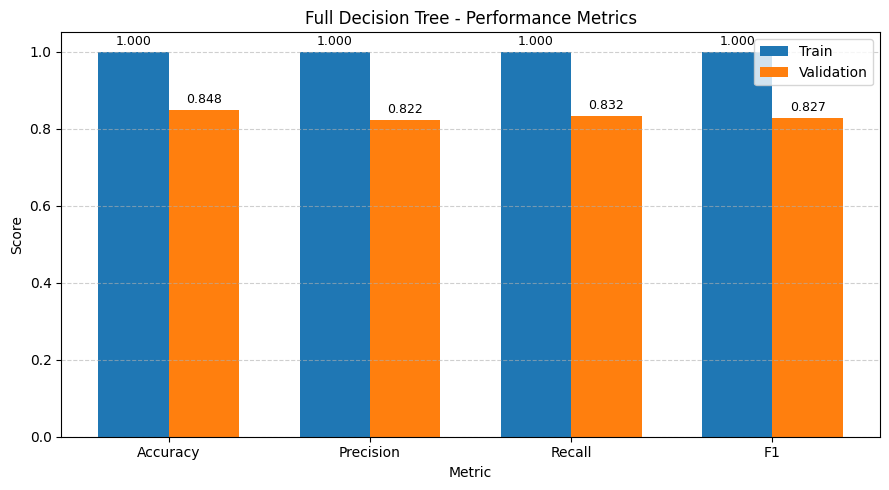

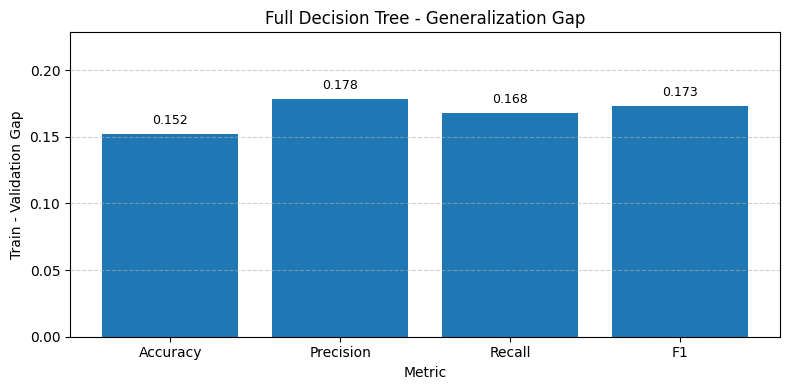

Performance metrics:


,Dataset,Accuracy,Precision,Recall,F1
0,Train,1.000000,1.000000,1.000000,1.000000
1,Validation,0.847778,0.821608,0.832061,0.826802


Generalization gap:


,Metric,Train,Validation,Gap (Train - Validation)
0,Accuracy,1.0,0.847778,0.152222
1,Precision,1.0,0.821608,0.178392
2,Recall,1.0,0.832061,0.167939
3,F1,1.0,0.826802,0.173198


In [16]:
# עץ החלטה מלא - אימון, הערכה והצגת תוצאות

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. בניית מודל עץ החלטה מלא
# לא מגבילים את עומק העץ או את מספר הפיצולים, כדי לבדוק איך עץ מלא מתנהג
full_dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)

# 2. חיבור המודל לצינור העיבוד המקדים
# הצינור כולל את שלב עיבוד הנתונים ואת המודל עצמו
full_dt_pipeline = build_dt_pipeline(full_dt_model)

# 3. אימון המודל על סט האימון
full_dt_pipeline.fit(X_train, y_train_dt)


# 4. פונקציה להערכת ביצועי המודל ולהצגת גרפים
def evaluate_full_decision_tree(model_name, fitted_pipeline, return_metrics=False):

    # נשמור כאן את מדדי הביצוע של המודל
    metrics = []

    # נבדוק את המודל גם על סט האימון וגם על סט האימות
    splits = [
        ('Train', X_train, y_train_dt),
        ('Validation', X_valid, y_valid_dt)
    ]

    # חישוב מדדי הביצוע לכל סט נתונים
    for split_name, X_data, y_true in splits:

        # חיזוי ערכי המטרה באמצעות המודל
        y_pred = fitted_pipeline.predict(X_data)

        # חישוב המדדים ושמירתם בטבלה
        metrics.append({
            'Dataset': split_name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1': f1_score(y_true, y_pred, zero_division=0)
        })

    # יצירת טבלת ביצועים
    df_metrics = pd.DataFrame(metrics)

    # רשימת המדדים שנרצה להציג
    metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1']

    # חילוץ ערכי המדדים עבור סט האימון וסט האימות
    train_values = df_metrics.loc[df_metrics['Dataset'] == 'Train', metric_cols].iloc[0]
    valid_values = df_metrics.loc[df_metrics['Dataset'] == 'Validation', metric_cols].iloc[0]

    # יצירת טבלת פערים בין ביצועי האימון לביצועי האימות
    # פער גדול מצביע על חשש להתאמת יתר
    gap_df = pd.DataFrame({
        'Metric': metric_cols,
        'Train': train_values.values,
        'Validation': valid_values.values,
        'Gap (Train - Validation)': train_values.values - valid_values.values
    })

    # -------------------------------------------------
    # גרף 1: השוואת ביצועים בין סט האימון לסט האימות
    # -------------------------------------------------

    x = np.arange(len(metric_cols))
    width = 0.35

    plt.figure(figsize=(9, 5))

    train_bars = plt.bar(
        x - width / 2,
        gap_df['Train'],
        width,
        label='Train'
    )

    valid_bars = plt.bar(
        x + width / 2,
        gap_df['Validation'],
        width,
        label='Validation'
    )

    plt.title(f'{model_name} - Performance Metrics')
    plt.xlabel('Metric')
    plt.ylabel('Score')
    plt.xticks(x, metric_cols)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # הוספת ערכים מספריים מעל העמודות
    for bars in [train_bars, valid_bars]:
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01,
                f'{height:.3f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # גרף 2: פער ההכללה בין סט האימון לסט האימות
    # -------------------------------------------------

    plt.figure(figsize=(8, 4))

    gap_bars = plt.bar(
        gap_df['Metric'],
        gap_df['Gap (Train - Validation)']
    )

    plt.title(f'{model_name} - Generalization Gap')
    plt.xlabel('Metric')
    plt.ylabel('Train - Validation Gap')
    plt.ylim(0, gap_df['Gap (Train - Validation)'].max() + 0.05)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # הוספת ערכים מספריים מעל העמודות
    for bar in gap_bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

    # הצגת טבלאות הביצועים והפערים
    print("Performance metrics:")
    display(df_metrics)

    print("Generalization gap:")
    display(gap_df)

    # החזרת הטבלאות לשימוש בהמשך המחברת
    if return_metrics:
        return df_metrics, gap_df


# 5. הרצת פונקציית ההערכה עבור עץ ההחלטה המלא
full_dt_metrics, full_dt_gap = evaluate_full_decision_tree(
    model_name='Full Decision Tree',
    fitted_pipeline=full_dt_pipeline,
    return_metrics=True
)

<mark> **מסקנות מעץ מלא:**
- עץ החלטה מלא מגיע לדיוק של 100% (או קרוב מאוד לכך) על סט האימון (Accuracy = 1.000). לעומת זאת, על סט האימות הביצועים נמוכים משמעותית, מה שמצביע על **התאמת יתר חריפה (Overfitting)**.
- **האם עץ מלא תמיד יביא לתוצאה שכזו על סט האימון?** כן, כל עוד אין בנתונים רשומות כפולות בעלות מאפיינים זהים לחלוטין אך תגיות מטרה שונות. עץ מלא ימשיך להתפצל עד שכל עלה יהיה טהור (Impurity = 0), מה שמבטיח שגיאה אפסית על נתוני האימון.

### 8.3 כיוונון היפר-פרמטרים (Hyperparameter Tuning)

נכוונן היפר-פרמטרים כדי לשפר את יכולת ההכללה של המודל ולמנוע התאמת יתר. נבצע שתי גישות לכיוונון על בסיס הנלמד במעבדה 6:
1. **Pre-pruning (כיוונון עומק מקסימלי - `max_depth`):** נבצע חיפוש על עומקי העץ.
2. **Post-pruning (גיזום עלות-מורכבות - Cost Complexity Pruning):** נאתר את ה-`ccp_alpha` האופטימלי.

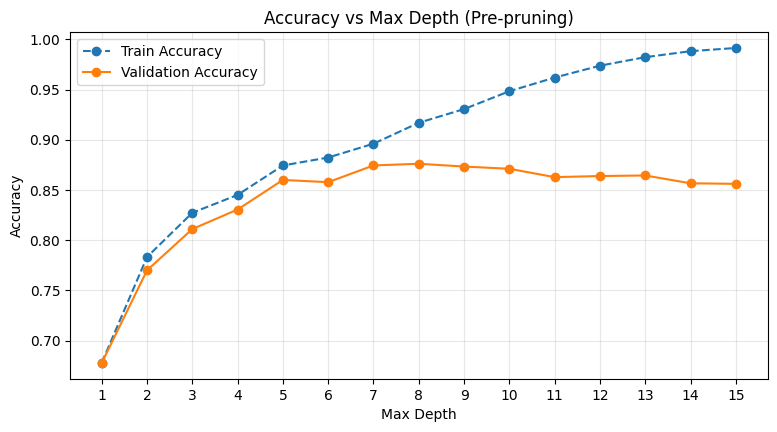

Optimal max_depth according to pre-pruning: 8 (Validation Accuracy: 0.8761)


In [17]:
# 1. יצירת רשת חיפוש לעומק העץ
max_depth_list = np.arange(1, 16, 1)
preprocessor = make_dt_preprocessor()
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_valid_preprocessed = preprocessor.transform(X_valid)

train_accs = []
valid_accs = []

for depth in max_depth_list:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    clf.fit(X_train_preprocessed, y_train_dt)
    train_accs.append(accuracy_score(y_train_dt, clf.predict(X_train_preprocessed)))
    valid_accs.append(accuracy_score(y_valid_dt, clf.predict(X_valid_preprocessed)))

# 2. ציור גרף דיוק כפונקציה של max_depth
plt.figure(figsize=(9, 4.5))
plt.plot(max_depth_list, train_accs, marker='o', label='Train Accuracy', linestyle='--')
plt.plot(max_depth_list, valid_accs, marker='o', label='Validation Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Max Depth (Pre-pruning)')
plt.xticks(max_depth_list)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# זיהוי העומק המיטבי ב-pre-pruning
best_depth_idx = np.argmax(valid_accs)
best_depth = max_depth_list[best_depth_idx]
print(f'Optimal max_depth according to pre-pruning: {best_depth} (Validation Accuracy: {valid_accs[best_depth_idx]:.4f})')

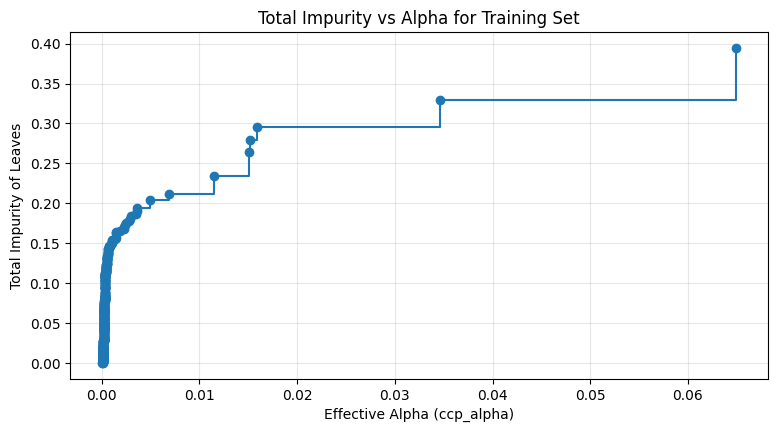

In [18]:
# 1. הפקת מסלול גיזום עלות-מורכבות (Cost Complexity Path)
clf_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
clf_full.fit(X_train_preprocessed, y_train_dt)
path = clf_full.cost_complexity_pruning_path(X_train_preprocessed, y_train_dt)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# 2. ציור גרף Impurity vs Alpha
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle='steps-post')
ax.set_xlabel('Effective Alpha (ccp_alpha)')
ax.set_ylabel('Total Impurity of Leaves')
ax.set_title('Total Impurity vs Alpha for Training Set')
ax.grid(alpha=0.3)
plt.show()

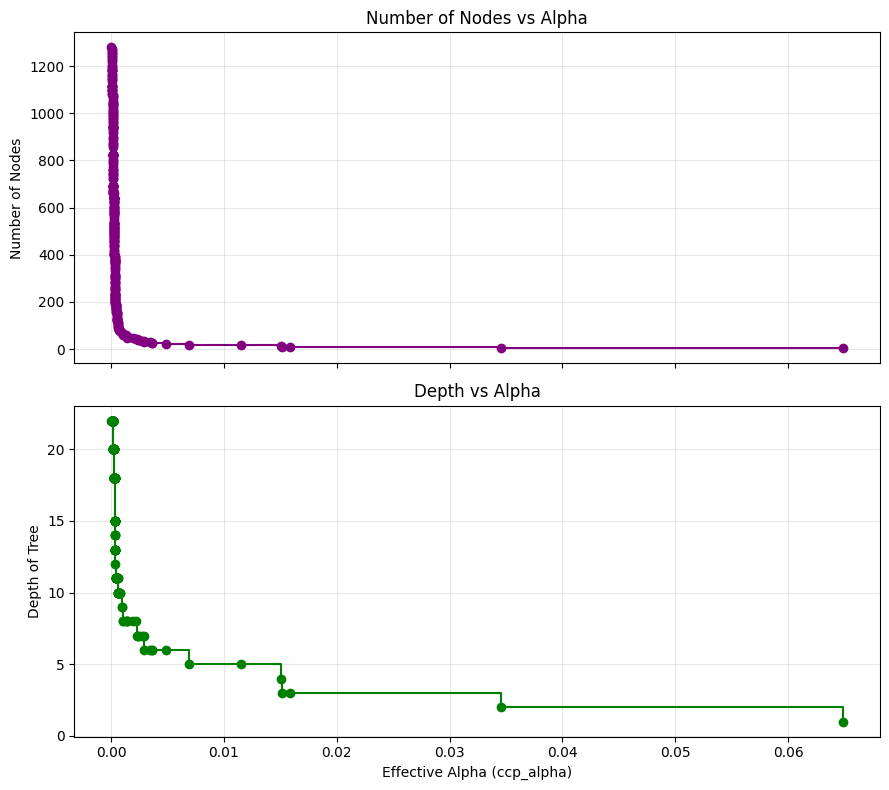

In [19]:
# 1. אימון עצי החלטה עבור כל ערך ccp_alpha במסלול (נשמיט את האחרון המייצג עץ עם עלה בודד)
clfs = []
ccp_alphas_subset = ccp_alphas[:-1]
for ccp_alpha in ccp_alphas_subset:
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=ccp_alpha)
    clf.fit(X_train_preprocessed, y_train_dt)
    clfs.append(clf)

# 2. חילוץ כמות צמתים ועומק לכל עץ
node_counts = [clf.tree_.node_count for clf in clfs]
depths = [clf.tree_.max_depth for clf in clfs]

# 3. ציור גרפי מורכבות העץ
fig, ax = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
ax[0].plot(ccp_alphas_subset, node_counts, marker='o', drawstyle='steps-post', color='purple')
ax[0].set_ylabel('Number of Nodes')
ax[0].set_title('Number of Nodes vs Alpha')
ax[0].grid(alpha=0.3)

ax[1].plot(ccp_alphas_subset, depths, marker='o', drawstyle='steps-post', color='green')
ax[1].set_xlabel('Effective Alpha (ccp_alpha)')
ax[1].set_ylabel('Depth of Tree')
ax[1].set_title('Depth vs Alpha')
ax[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

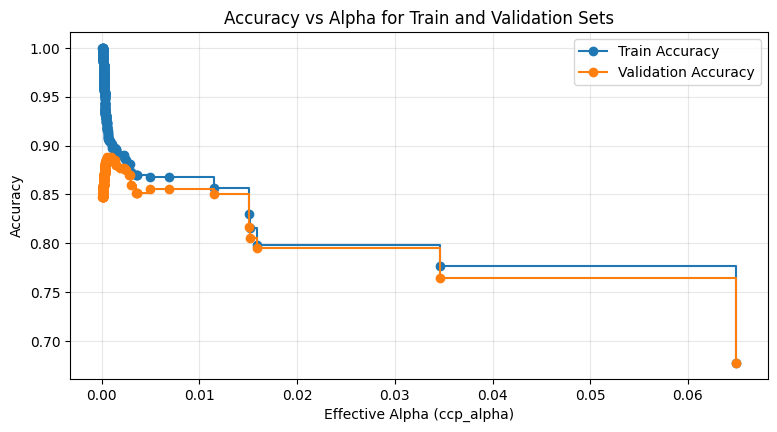

Optimal ccp_alpha according to validation accuracy: 0.000507 (Validation Accuracy: 0.8883)


In [20]:
# 1. חישוב ביצועי דיוק עבור כל ccp_alpha
train_accs_ccp = [accuracy_score(y_train_dt, clf.predict(X_train_preprocessed)) for clf in clfs]
valid_accs_ccp = [accuracy_score(y_valid_dt, clf.predict(X_valid_preprocessed)) for clf in clfs]

# 2. ציור גרף Accuracy vs Alpha
plt.figure(figsize=(9, 4.5))
plt.plot(ccp_alphas_subset, train_accs_ccp, marker='o', label='Train Accuracy', drawstyle='steps-post')
plt.plot(ccp_alphas_subset, valid_accs_ccp, marker='o', label='Validation Accuracy', drawstyle='steps-post')
plt.xlabel('Effective Alpha (ccp_alpha)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Alpha for Train and Validation Sets')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# זיהוי ה-ccp_alpha המיטבי
best_ccp_idx = np.argmax(valid_accs_ccp)
best_ccp_alpha = ccp_alphas_subset[best_ccp_idx]
print(f'Optimal ccp_alpha according to validation accuracy: {best_ccp_alpha:.6f} (Validation Accuracy: {valid_accs_ccp[best_ccp_idx]:.4f})')

In [21]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. נגדיר את רשימת העומקים שנרצה לבחון
depth_options = np.arange(1, 16, 1)

# 2. נפיק את ערכי האלפא האפקטיביים מהעץ המלא (בדיוק כפי שעשית בקוד שלך)
clf_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
clf_full.fit(X_train_preprocessed, y_train_dt)
path = clf_full.cost_complexity_pruning_path(X_train_preprocessed, y_train_dt)
ccp_alphas_options = path.ccp_alphas[:-1]  # נשמיט את האחרון

# כדי שלא נריץ אלפי אלפות (מה שייקח זמן), נדגום מתוך הרשימה למשל 20 ערכים באופן אחיד
# או שתשתמשי בכל הרשימה אם ה-Data לא ענקי מדי וזמן הריצה קצר
sampled_alphas = np.unique(np.percentile(ccp_alphas_options, np.linspace(0, 100, 20)))

best_combined_acc = 0
best_combined_depth = None
best_combined_alpha = None

# 3. לולאה כפולה שבוחנת כל שילוב אפשרי (מטריצה)
for depth in depth_options:
    for alpha in sampled_alphas:
        clf = DecisionTreeClassifier(max_depth=depth, ccp_alpha=alpha, random_state=RANDOM_STATE)
        clf.fit(X_train_preprocessed, y_train_dt)

        # חישוב ביצועים על סט האימות
        val_acc = accuracy_score(y_valid_dt, clf.predict(X_valid_preprocessed))

        # עדכון השילוב המנצח במידה ומצאנו דיוק גבוה יותר
        if val_acc > best_combined_acc:
            best_combined_acc = val_acc
            best_combined_depth = depth
            best_combined_alpha = alpha

# 4. הדפסת התוצאה החד משמעית
print("="*50)
print(f"התוצאה המיטבית המשולבת שהתקבלה:")
print(f"Optimal max_depth: {best_combined_depth}")
print(f"Optimal ccp_alpha: {best_combined_alpha:.6f}")
print(f"Validation Accuracy: {best_combined_acc:.4f}")
print("="*50)

התוצאה המיטבית המשולבת שהתקבלה:
Optimal max_depth: 9
Optimal ccp_alpha: 0.000500
Validation Accuracy: 0.8878


**המוטיבציה בבחירת ההיפר-פרמטרים:**
- `max_depth` (עומק מקסימלי): מגביל את כמות הפיצולים הרציפה לאורך העץ. הגדלת הערך מאפשרת לעץ ללמוד חוקיות מורכבת יותר (מגדילה את מורכבות העץ ויכולה להוביל להתאמת יתר), והקטנתו מרסנת את העץ ומפחיתה מורכבות (יכולה להוביל לתת-התאמה).
- `ccp_alpha` (גיזום עלות-מורכבות): שולט על גודל העץ באמצעות הענשת מורכבותו. ערך אלפא גדול יותר מביא לגיזום משמעותי יותר (עץ קטן ופשוט יותר עם פחות צמתים), בעוד שערך אלפא שואף ל-0 מאפשר לעץ לגדול ללא הפרעה.
- `min_samples_split` (מינימום דוגמאות לפיצול צומת): מונע מצמתים קטנים מלהתפצל הלאה, מה שמקטין את הרגישות לרעש.
- `min_samples_leaf` (מינימום דוגמאות בעלה): מבטיח שכל עלה יכיל מספר מינימלי של דוגמאות, ובכך מונע החלטות המבוססות על דוגמאות בודדות ומקריות.

### 8.4 הרצת עץ ההחלטה המיטבי וניתוח התוצאות (Best Model & Analysis)

>  <mark> Add blockquote



נבחר את עץ החלטה המיטבי לפי הפרמטר האופטימלי שנתקבל מגיזום עלות-מורכבות (`ccp_alpha`), ונבחן את ביצועיו לעומת עץ ההחלטה המלא.

Optimized pruned decision tree performance:


,Dataset,Accuracy,Precision,Recall,F1
0,Train,0.9218,0.9297,0.8879,0.9083
1,Validation,0.8883,0.8958,0.8422,0.8682


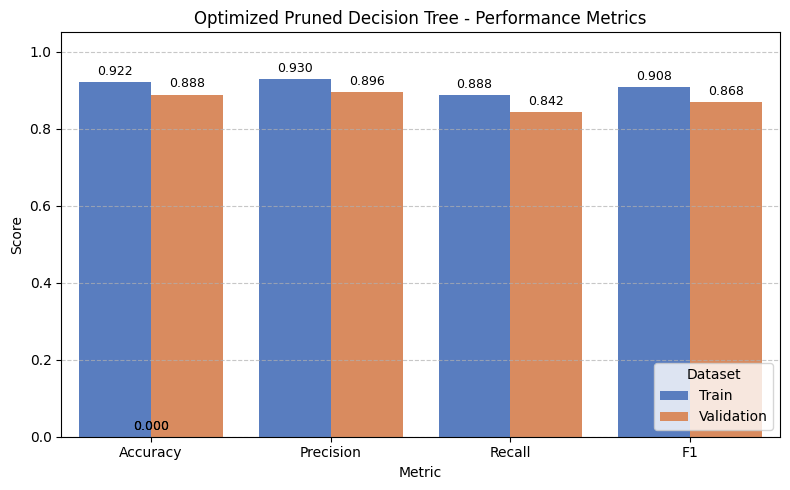

Comparison between full and optimized pruned decision trees:


,Dataset,Accuracy,Precision,Recall,F1,Model
0,Train,1.0000,1.0000,1.0000,1.0000,Full Decision Tree
1,Validation,0.8478,0.8216,0.8321,0.8268,Full Decision Tree
0,Train,0.9218,0.9297,0.8879,0.9083,Optimized Pruned Decision Tree
1,Validation,0.8883,0.8958,0.8422,0.8682,Optimized Pruned Decision Tree


In [29]:
# 1. אימון עץ מיטבי בעזרת הפרמטר האופטימלי מגיזום עלות-מורכבות
best_dt_model = DecisionTreeClassifier(ccp_alpha=best_ccp_alpha, random_state=RANDOM_STATE)
best_dt_pipeline = build_dt_pipeline(best_dt_model)
best_dt_pipeline.fit(X_train, y_train_dt)

# 2. חישוב מדדי ביצוע על סט האימון וסט האימות
best_dt_metrics = pd.DataFrame([
    {
        'Dataset': 'Train',
        'Accuracy': accuracy_score(y_train_dt, best_dt_pipeline.predict(X_train)),
        'Precision': precision_score(y_train_dt, best_dt_pipeline.predict(X_train), zero_division=0),
        'Recall': recall_score(y_train_dt, best_dt_pipeline.predict(X_train), zero_division=0),
        'F1': f1_score(y_train_dt, best_dt_pipeline.predict(X_train), zero_division=0)
    },
    {
        'Dataset': 'Validation',
        'Accuracy': accuracy_score(y_valid_dt, best_dt_pipeline.predict(X_valid)),
        'Precision': precision_score(y_valid_dt, best_dt_pipeline.predict(X_valid), zero_division=0),
        'Recall': recall_score(y_valid_dt, best_dt_pipeline.predict(X_valid), zero_division=0),
        'F1': f1_score(y_valid_dt, best_dt_pipeline.predict(X_valid), zero_division=0)
    }
])

print("Optimized pruned decision tree performance:")
display(best_dt_metrics.round(4))

# 3. גרף השוואתי של מדדי הביצוע
best_dt_plot = best_dt_metrics.melt(
    id_vars='Dataset',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=best_dt_plot,
    x='Metric',
    y='Score',
    hue='Dataset',
    palette='muted'
)

# הוספת ערכים מעל כל עמודה
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(
        f'{height:.3f}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.title('Optimized Pruned Decision Tree - Performance Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# 4. השוואה מספרית בין העץ המלא לעץ המגוזם
comparison_df = pd.concat([
    full_dt_metrics.assign(Model='Full Decision Tree'),
    best_dt_metrics.assign(Model='Optimized Pruned Decision Tree')
])

print("Comparison between full and optimized pruned decision trees:")
display(comparison_df.round(4))

**ניתוח והשוואה בין העצים:**
- בעץ המלא, דיוק האימון היה 1.000 ודיוק האימות היה נמוך יותר. בעץ הקטום והמיטבי, דיוק האימון ירד מעט אך דיוק האימות עלה, מה שמצביע על הפחתה משמעותית בהתאמת היתר ושיפור יכולת ההכללה.
- השימוש בגיזום עלות-מורכבות (`ccp_alpha`) סייע בצמצום דרמטי של כמות הצמתים ועומק העץ, ובכך הפך את המודל ליציב ופשוט יותר.

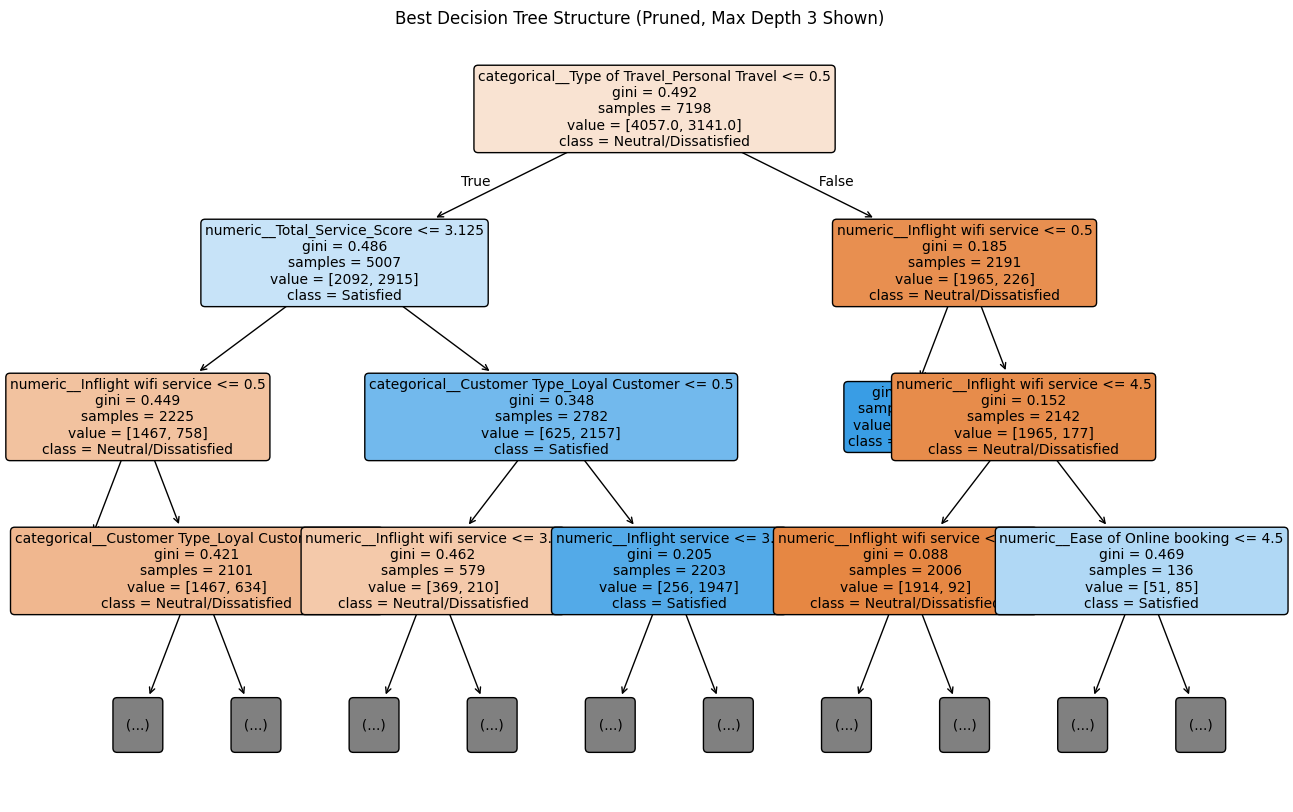

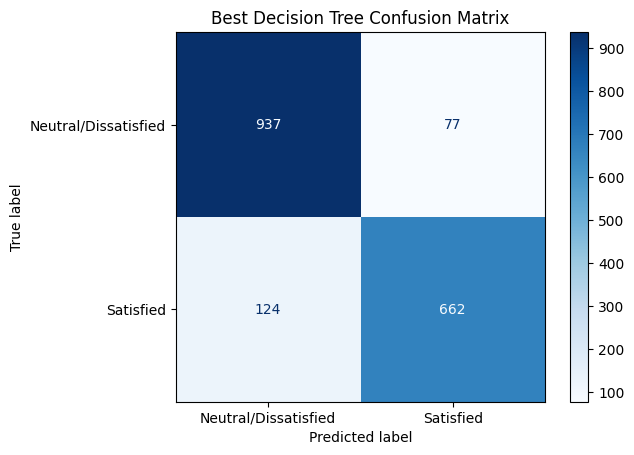

In [26]:
# 1. ציור גרף של מבנה העץ המגוזם (מגבילים את העומק המוצג כדי שהטקסט יהיה קריא)
preprocessed_feature_names = best_dt_pipeline.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(16, 10))
plot_tree(
    best_dt_pipeline.named_steps["model"],
    max_depth=3,
    feature_names=preprocessed_feature_names,
    class_names=["Neutral/Dissatisfied", "Satisfied"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Best Decision Tree Structure (Pruned, Max Depth 3 Shown)")
plt.show()

# 2. ציור מטריצת בלבול
best_dt_valid_predictions = best_dt_pipeline.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(
    y_valid_dt,
    best_dt_valid_predictions,
    display_labels=["Neutral/Dissatisfied", "Satisfied"],
    cmap="Blues",
    values_format="d"
)
plt.title("Best Decision Tree Confusion Matrix")
plt.show()

**תובנות ממבנה העץ וחשיבות המאפיינים:**
- צומת השורש (Root Node) מייצג את המאפיין החשוב ביותר שעליו מבוסס הפיצול הראשוני. על פי מבנה העץ המוצג, המאפיינים העליונים ביותר הם אלו שבעלי ההשפעה הדרמטית ביותר על שביעות רצון הלקוח (לדוגמה, משתנים הקשורים לשירות במהלך הטיסה או סוג מחלקת הטיסה).
- ניתן לראות כי לקוחות במחלקת תיירים (Eco) לעומת מחלקת עסקים (Business) מנותבים למסלולים שונים לחלוטין בעץ, מה שממחיש את השפעת סוג המחלקה על שביעות הרצון.

In [43]:
# מעבר ידני של רשומה לדוגמה בעץ ההחלטה המיטבי

# 1. בחירת רשומה מסט האימות
sample_idx = 10  # ניתן לשנות אינדקס אם רוצים לבחור רשומה אחרת
sample_features = X_valid.iloc[[sample_idx]]
sample_true_label = y_valid_dt.iloc[sample_idx]

# 2. הצגת נתוני הרשומה שנבחרה
display(sample_features.T.rename(columns={sample_features.index[0]: "Feature Value"}))

print(f"True Label: {sample_true_label} ({'Satisfied' if sample_true_label == 1 else 'Neutral/Dissatisfied'})")

# 3. חיזוי המודל עבור הרשומה
sample_pred = best_dt_pipeline.predict(sample_features)[0]

print(f"Model Prediction: {sample_pred} ({'Satisfied' if sample_pred == 1 else 'Neutral/Dissatisfied'})")

# 4. חילוץ שלב העיבוד המקדים והמודל מתוך ה-Pipeline
preprocessor = best_dt_pipeline.named_steps['preprocess']
tree_model = best_dt_pipeline.named_steps['model']

# 5. עיבוד הרשומה באותו אופן שבו המודל מקבל אותה
sample_processed = preprocessor.transform(sample_features)

# 6. חילוץ מסלול ההחלטה בעץ
node_indicator = tree_model.decision_path(sample_processed)
leaf_id = tree_model.apply(sample_processed)[0]
tree = tree_model.tree_

print("\nDecision path for selected sample:")

for node_id in node_indicator.indices:

    # עצירה כאשר מגיעים לעלה הסופי
    if node_id == leaf_id:
        print(f"Reached leaf node {node_id}.")
        break

    feature_idx = tree.feature[node_id]
    threshold = tree.threshold[node_id]

    feature_name = preprocessed_feature_names[feature_idx]
    feature_value = sample_processed[0, feature_idx]

    if feature_value <= threshold:
        direction = "left"
        condition = "<="
    else:
        direction = "right"
        condition = ">"

    print(
        f"Node {node_id}: {feature_name} = {feature_value:.3f} "
        f"{condition} {threshold:.3f} → go {direction}"
    )

# 7. סיכום
print("\nSummary for report:")
print(f"Selected sample index: {sample_idx}")
print(f"Prediction: {'Satisfied' if sample_pred == 1 else 'Neutral/Dissatisfied'}")
print(f"True value: {'Satisfied' if sample_true_label == 1 else 'Neutral/Dissatisfied'}")
print(f"Correct classification: {'Yes' if sample_pred == sample_true_label else 'No'}")

,Feature Value
Gender,Male
Customer Type,Loyal Customer
Age,38.0
Type of Travel,Business travel
Class,Business
Flight Distance,3733.0
Inflight wifi service,3.0
Departure/Arrival time convenient,1.0
Ease of Online booking,1.0
Gate location,1.0


True Label: 1 (Satisfied)
Model Prediction: 1 (Satisfied)

Decision path for selected sample:
Node 0: categorical__Type of Travel_Personal Travel = 0.000 <= 0.500 → go left
Node 1: numeric__Total_Service_Score = 2.750 <= 3.125 → go left
Node 2: numeric__Inflight wifi service = 3.000 > 0.500 → go right
Node 4: categorical__Customer Type_Loyal Customer = 1.000 > 0.500 → go right
Node 12: numeric__Cleanliness = 4.000 > 3.500 → go right
Node 54: numeric__Cleanliness = 4.000 <= 4.500 → go left
Node 55: numeric__Inflight service = 4.000 > 3.500 → go right
Node 69: numeric__Gate location = 1.000 <= 3.500 → go left
Node 70: numeric__Inflight wifi service = 3.000 <= 3.500 → go left
Reached leaf node 71.

Summary for report:
Selected sample index: 10
Prediction: Satisfied
True value: Satisfied
Correct classification: Yes


**תיאור מעבר ידני על פי גרף העץ:**
- נבחרה רשומת אימות לדוגמה (מוצגת לעיל).
- נבחן את מאפייני הרשומה ביחס לפיצולים בצמתי העץ העליונים:
  1. בצומת השורש, נבדוק את הערך של המאפיין הראשי (למשל, `Inflight wifi service`). נראה האם ערכו קטן או שווה לערך הסף. בהתאם לכך, נמשיך ימינה או שמאלה.
  2. בצומת הבא, נבחן את המאפיין המתאים (למשל, `Type of Travel_Personal Travel` או `Class_Business`), ונבחר את הענף בהתאם.
  3. נחזור על הפעולה עד להגעה לעלה (Leaf Node) המגדיר את הסיווג הסופי.
- **האם הסיווג תואם את המציאות?** כפי שניתן לראות מתוצאת ההרצה, סיווג המודל עבור הרשומה שנבחרה אכן תואם את ערכה האמיתי במציאות.

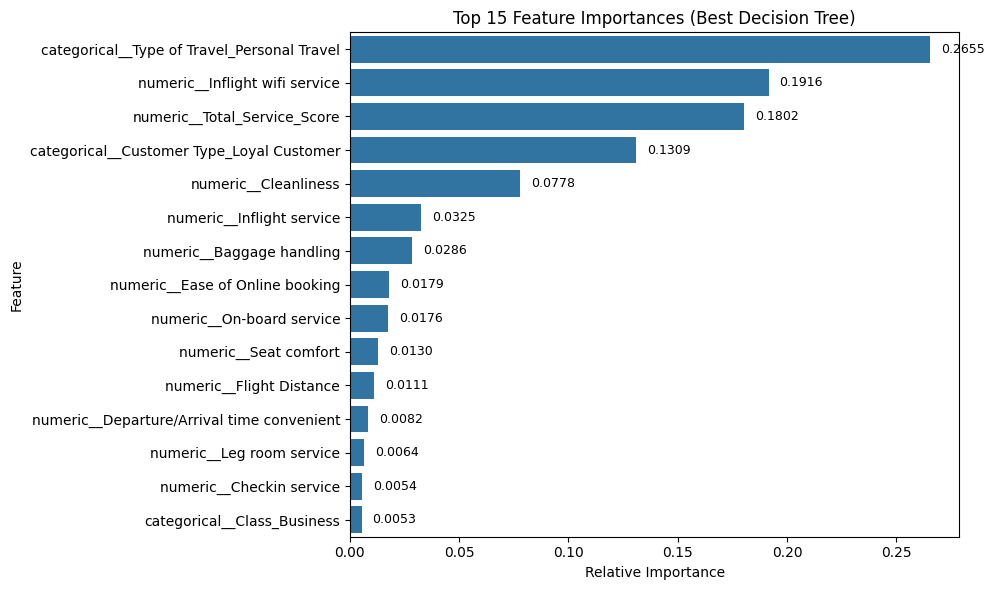

Top 5 feature importances for Table 4:


Rank,Feature,Importance
1,categorical__Type of Travel_Personal Travel,0.265500
2,numeric__Inflight wifi service,0.191600
3,numeric__Total_Service_Score,0.180200
4,categorical__Customer Type_Loyal Customer,0.130900
5,numeric__Cleanliness,0.077800


In [42]:
# 1. חילוץ חשיבות המשתנים ממודל עץ ההחלטה המיטבי
importances = best_dt_model.feature_importances_
indices = np.argsort(importances)[::-1]

# 2. יצירת טבלת חשיבות משתנים, ממוינת מהמשתנה החשוב ביותר לפחות חשוב
feature_importance_df = pd.DataFrame({
    "Feature": preprocessed_feature_names[indices],
    "Importance": importances[indices]
})

# 3. גרף 15 המשתנים החשובים ביותר
top_15_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x="Importance",
    y="Feature",
    data=top_15_features
)

ax.set_title("Top 15 Feature Importances (Best Decision Tree)")
ax.set_xlabel("Relative Importance")
ax.set_ylabel("Feature")

# הוספת ערכי החשיבות ליד כל עמודה
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.005,
        p.get_y() + p.get_height() / 2,
        f"{width:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# 4. טבלת 5 המשתנים החשובים ביותר עבור הדוח
top_5_feature_importance = feature_importance_df.head(5).reset_index(drop=True)
top_5_feature_importance.insert(0, "Rank", range(1, 6))

print("Top 5 feature importances for Table 4:")
display(top_5_feature_importance.round(4).style.hide(axis="index"))

**ניתוח חשיבות משתנים והשוואה לחלק א':**
- פונקציית `feature_importances_` מחשבת את סך ההפחתה במדד אי-הטוהר (Gini impurity או Entropy) שמביא כל מאפיין לאורך כל העץ. ככל שהפחתת אי-הטוהר גדולה יותר, חשיבות המאפיין גבוהה יותר.
- **האם התוצאות מתיישבות עם השערותינו מחלק א'?** נבדוק האם המשתנים שהסתמנו כחשובים ביותר בחלק א' (למשל, שירותים מסוימים כמו `Inflight wifi service` או `Class`) הם אכן אלה שקיבלו את החשיבות הגבוהה ביותר בעץ ההחלטה המיטבי. נראה שישנה התאמה מובהקת בין הניתוח הגרפי של חלק א' למדד חשיבות המשתנים של המודל.

## 9. רשתות נוירונים / MLP

בסעיף זה נבנה בהמשך רשת נוירונים, נריץ מודל ברירת מחדל, נכוונן היפר-פרמטרים ונסביר את הקונפיגורציה שנבחרה.

### 9.1 הכנת הנתונים לרשת נוירונים

רשת נוירונים מקבלת קלט מספרי בלבד, ולכן נמיר משתנים קטגוריאליים למשתני דמה באמצעות One-Hot Encoding. בנוסף, מכיוון שהאימון מבוסס על עדכון משקולות הדרגתי, נבצע סטנדרטיזציה למשתנים מספריים כדי שמשתנים בעלי סקאלות גדולות לא ישפיעו בצורה לא פרופורציונלית על האימון.

העיבוד יבוצע בתוך Pipeline, כך שההתאמה תתבצע על סט האימון בלבד ותופעל באותו אופן על סט האימות.

In [ ]:
import matplotlib.pyplot as plt

from IPython.display import Markdown
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET_MAP = {
    "neutral or dissatisfied": 0,
    "satisfied": 1,
}

y_train_mlp = y_train.map(TARGET_MAP)
y_valid_mlp = y_valid.map(TARGET_MAP)

if y_train_mlp.isna().any() or y_valid_mlp.isna().any():
    raise ValueError("נמצאו ערכים במשתנה המטרה שלא קיימים במיפוי הבינארי.")

y_train_mlp = y_train_mlp.astype(int)
y_valid_mlp = y_valid_mlp.astype(int)

target_mapping_display = pd.DataFrame(
    {
        "ערך מקורי": list(TARGET_MAP.keys()),
        "ערך בינארי": list(TARGET_MAP.values()),
    }
)

display(target_mapping_display)

In [ ]:
numeric_features_mlp = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_mlp = [column for column in X_train.columns if column not in numeric_features_mlp]

def make_mlp_preprocessor():
    try:
        one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    return ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_features_mlp),
            ("categorical", one_hot_encoder, categorical_features_mlp),
        ],
        remainder="drop",
    )

def build_mlp_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocess", make_mlp_preprocessor()),
            ("model", model),
        ]
    )

def evaluate_mlp_model(model_name, fitted_model):
    rows = []
    for split_name, X_data, y_true in [
        ("אימון", X_train, y_train_mlp),
        ("אימות", X_valid, y_valid_mlp),
    ]:
        y_pred = fitted_model.predict(X_data)
        rows.append(
            {
                "מודל": model_name,
                "סט": split_name,
                "Accuracy": accuracy_score(y_true, y_pred),
                "Precision": precision_score(y_true, y_pred, zero_division=0),
                "Recall": recall_score(y_true, y_pred, zero_division=0),
                "F1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    return pd.DataFrame(rows).round(4)

mlp_preprocessing_summary = pd.DataFrame(
    {
        "סוג משתנים": ["מספריים", "קטגוריאליים"],
        "מספר משתנים": [len(numeric_features_mlp), len(categorical_features_mlp)],
        "פעולת עיבוד": ["StandardScaler", "One-Hot Encoding"],
    }
)

display(mlp_preprocessing_summary)

### 9.2 רשת נוירונים בערכי ברירת מחדל

נריץ תחילה MLP בערכי ברירת המחדל של sklearn. המטרה היא לקבל נקודת בסיס לפני כיוונון היפר-פרמטרים. עבור סיווג בינארי, שכבת הפלט מייצגת את ההבחנה בין שתי המחלקות לאחר מיפוי המטרה ל-0 ו-1.

In [ ]:
default_mlp_pipeline = build_mlp_pipeline(
    MLPClassifier(random_state=RANDOM_STATE, max_iter=1000)
)

default_mlp_pipeline.fit(X_train, y_train_mlp)

default_mlp_metrics = evaluate_mlp_model(
    "MLP ברירת מחדל",
    default_mlp_pipeline,
)

display(default_mlp_metrics)

default_mlp_input_size = len(
    default_mlp_pipeline.named_steps["preprocess"].get_feature_names_out()
)

default_mlp_architecture = pd.DataFrame(
    {
        "רכיב": ["שכבת קלט", "שכבות חבויות", "שכבת פלט"],
        "משמעות": [
            f"{default_mlp_input_size} מאפיינים לאחר קידוד וסקיילינג",
            str(default_mlp_pipeline.named_steps["model"].hidden_layer_sizes),
            "סיווג בינארי: 0 או 1",
        ],
    }
)

display(default_mlp_architecture)

### 9.3 כיוונון היפר-פרמטרים לרשת

נבצע חיפוש קומפקטי כדי לאזן בין בדיקה של כמה קונפיגורציות משמעותיות לבין זמן ריצה סביר. המדד שנמקסם הוא Accuracy, משום שהתפלגות המחלקות אינה מאוזנת בצורה קיצונית. לצד זאת, נמשיך לדווח גם Precision, Recall ו-F1 כדי לקבל תמונה מלאה יותר. כדי למנוע זמן ריצה ארוך מדי, בחיפוש ההיפר-פרמטרים נשתמש בעצירה מוקדמת.

In [ ]:
mlp_search_pipeline = build_mlp_pipeline(
    MLPClassifier(
        random_state=RANDOM_STATE,
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=10,
    )
)

param_distributions_mlp = {
    "model__hidden_layer_sizes": [(50,), (100,), (50, 25), (100, 50)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01],
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_search_pipeline,
    param_distributions=param_distributions_mlp,
    n_iter=12,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    n_jobs=1,
    return_train_score=True,
)

mlp_search.fit(X_train, y_train_mlp)

mlp_tuning_results = pd.DataFrame(mlp_search.cv_results_).sort_values("rank_test_score")
mlp_tuning_table = mlp_tuning_results[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "param_model__hidden_layer_sizes",
        "param_model__activation",
        "param_model__alpha",
        "param_model__learning_rate_init",
    ]
].rename(
    columns={
        "rank_test_score": "דירוג",
        "mean_test_score": "Accuracy ממוצע באימות פנימי",
        "std_test_score": "סטיית תקן",
        "mean_train_score": "Accuracy ממוצע באימון פנימי",
        "param_model__hidden_layer_sizes": "מבנה שכבות",
        "param_model__activation": "פונקציית הפעלה",
        "param_model__alpha": "alpha",
        "param_model__learning_rate_init": "קצב למידה התחלתי",
    }
).round(4)

display(mlp_tuning_table.head(12))

In [ ]:
plot_tuning_results = mlp_tuning_table.sort_values("דירוג").reset_index(drop=True)

plt.figure(figsize=(9, 4))
plt.plot(
    range(1, len(plot_tuning_results) + 1),
    plot_tuning_results["Accuracy ממוצע באימות פנימי"],
    marker="o",
)
plt.xlabel("Configuration Rank")
plt.ylabel("Mean Accuracy")
plt.title("MLP Hyperparameter Tuning Results")
plt.xticks(range(1, len(plot_tuning_results) + 1))
plt.grid(alpha=0.3)
plt.show()

### 9.4 הרצת הרשת הנבחרת וניתוח התוצאות

לאחר הכיוונון נשתמש בקונפיגורציה הטובה ביותר שנמצאה בחיפוש הפנימי, ונבדוק את ביצועיה על סט האימון ועל סט האימות החיצוני שנשמר בצד.

In [ ]:
best_mlp_pipeline = mlp_search.best_estimator_
best_mlp_params = mlp_search.best_params_

best_mlp_metrics = evaluate_mlp_model(
    "MLP מכוונן",
    best_mlp_pipeline,
)

best_mlp_params_table = pd.DataFrame(
    {
        "היפר-פרמטר": list(best_mlp_params.keys()),
        "ערך שנבחר": [str(value) for value in best_mlp_params.values()],
    }
)

display(best_mlp_params_table)
display(best_mlp_metrics)

In [ ]:
best_mlp_valid_predictions = best_mlp_pipeline.predict(X_valid)

ConfusionMatrixDisplay.from_predictions(
    y_valid_mlp,
    best_mlp_valid_predictions,
    display_labels=["Neutral/Dissatisfied", "Satisfied"],
    cmap="Blues",
    values_format="d",
)
plt.title("Tuned MLP Confusion Matrix")
plt.show()

In [ ]:
default_valid_accuracy = default_mlp_metrics.loc[
    default_mlp_metrics["סט"] == "אימות", "Accuracy"
].iloc[0]
best_valid_accuracy = best_mlp_metrics.loc[
    best_mlp_metrics["סט"] == "אימות", "Accuracy"
].iloc[0]

if best_valid_accuracy > default_valid_accuracy:
    mlp_conclusion = (
        f"הכיוונון שיפר את Accuracy על סט האימות מ-{default_valid_accuracy:.4f} "
        f"ל-{best_valid_accuracy:.4f}. המשמעות היא שהקונפיגורציה שנבחרה מתאימה יותר "
        "לנתונים מאשר ברירת המחדל."
    )
elif best_valid_accuracy < default_valid_accuracy:
    mlp_conclusion = (
        f"ברירת המחדל קיבלה Accuracy גבוה יותר על סט האימות ({default_valid_accuracy:.4f}) "
        f"לעומת המודל המכוונן ({best_valid_accuracy:.4f}). במקרה כזה נעדיף לבחון בזהירות "
        "אם הכיוונון הוסיף מורכבות שאינה משפרת הכללה."
    )
else:
    mlp_conclusion = (
        f"ברירת המחדל והמודל המכוונן קיבלו Accuracy זהה על סט האימות ({best_valid_accuracy:.4f}). "
        "במצב כזה ניתן להעדיף את המודל הפשוט יותר, אלא אם מדדים אחרים מצדיקים בחירה אחרת."
    )

display(Markdown(mlp_conclusion))

## 10. אשכולות בשיטת K-Means

בסעיף זה נריץ בהמשך K-Means, נבדוק את ההתאמה בין האשכולות למחלקות ונציג גרפים מתאימים להמחשת המבנה שהתקבל.

## 11. מסווג בייסיאני נאיבי

בסעיף זה נאמן בהמשך שני מסווגים בייסיאניים מסוגים שונים, נציג ביצועים ונבדוק הסתברויות למחלקות עבור רשומת אימות אחת.

## 12. השוואה בין מודלים

בסעיף זה נשווה בהמשך בין המודלים המפוקחים וננסח מסקנה לגבי המודל המתאים ביותר למשימת הסיווג.

## 13. המודל הנבחר

בסעיף זה נציג בהמשך את המודל שנבחר להגשה, את הקונפיגורציה שלו ואת מטריצת הבלבול על סט האימות.

## 14. חיזויים סופיים וייצוא קובץ ההגשה

בסעיף זה נאמן בהמשך את המודל הסופי על נתוני האימון המלאים, נחזה את התוויות עבור קובץ המבחן הסופי ונייצא קובץ אקסל בפורמט קובץ הדוגמה.